<font size=10>**NETWORK**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

<font color='#BFD72' size=5>**RESEARCH QUESTION**: </font><font size=5>*Which companies have a dominant position in public procurement?*</font> 

**Data**: 
- [*Portal BASE*](https://www.base.gov.pt/Base4/pt/pesquisa/?type=contratos&texto=&adjudicante=&adjudicataria=&tipo=2&tipocontrato=0&cpv=&aqinfo=&desdeprazoexecucao=&ateprazoexecucao=&sel_price=price_11&desdeprecocontrato=&ateprecocontrato=&desdeprecoefectivo=&ateprecoefectivo=&sel_date=date_11&desdedatacontrato=2023-01-01&atedatacontrato=2026-03-31&desdedatapublicacao=&atedatapublicacao=&desdedatafecho=&atedatafecho=&pais=0&distrito=0&concelho=0)

- [*Treated Datasets*](https://dados.gov.pt/pt/datasets/contratos-publicos-portal-base-impic-contratos-de-2012-a-2026/#/resources)

**Group B**
- Beatriz Marques 20231605
- Maria Inês Santos 20231630
- Luís Soeiro 20211536
- Rodrigo Silva 20231602

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>  
- [1. Imports](#1)  
- [2. Data Integration](#2)  
- [3. First Network](#3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [50]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
import importlib
import os
import subprocess
import sys
import warnings
from collections import Counter
from datetime import datetime


import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import powerlaw
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    importlib.invalidate_caches()
    import openpyxl

import warnings
warnings.filterwarnings('ignore')

try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    importlib.invalidate_caches()
    import openpyxl

In [52]:
# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

# <font color='#BFD72F' size=6>**2. Data Integration**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [53]:
data = pd.read_csv('../data/preprocessed_data.csv')
# data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16989 entries, 0 to 16988
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idcontrato                   16989 non-null  int64  
 1   tipoContrato                 16989 non-null  str    
 2   tipoFimContrato              16972 non-null  str    
 3   CPV                          16989 non-null  str    
 4   adjudicante                  16989 non-null  str    
 5   adjudicatarios               16989 non-null  str    
 6   concorrentes                 14707 non-null  str    
 7   precoBaseProcedimento        16989 non-null  float64
 8   precoContratual              16989 non-null  float64
 9   PrecoTotalEfetivo            16989 non-null  float64
 10  dataDecisaoAdjudicacao       16989 non-null  str    
 11  dataCelebracaoContrato       16989 non-null  str    
 12  dataPublicacao               16989 non-null  str    
 13  dataFechoContrato          

In [54]:
data["dataPublicacao"] = pd.to_datetime(data["dataPublicacao"], errors='coerce')
data["dataCelebracaoContrato"] = pd.to_datetime(data["dataCelebracaoContrato"], errors='coerce')
data["dataDecisaoAdjudicacao"] = pd.to_datetime(data["dataDecisaoAdjudicacao"], errors='coerce')
data["dataFechoContrato"] = pd.to_datetime(data["dataFechoContrato"], errors='coerce')

# <font color='#BFD72F' size=6>**3. The Network**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)

## <font size=5>**3.1. How is Public Procurement Distributed?**</font> <a class="anchor" id="3.1"></a>

[Back to TOC](#toc)

In [55]:
def compute_weight(prices, mode="log_sum"):

    prices = np.array(prices)

    if mode == "sum_price":
        return prices.sum()

    elif mode == "avg_price":
        return prices.mean()

    elif mode == "log_sum":
        return np.log(prices).sum()

    elif mode == "log_mean":
        return np.log(prices).mean()

    else:
        raise ValueError(
            f"Unknown mode: {mode}. "
            f"Valid modes: sum_price, avg_price, log_sum, log_mean"
        )

In [56]:
def _ensure_dataframe(data):
    if isinstance(data, pd.DataFrame):
        return data.copy()

    if isinstance(data, dict):
        # CASE 1: dict of lists (valid dataframe)
        try:
            df = pd.DataFrame(data)
            return df
        except Exception:
            pass

        # CASE 2: dict of scalars → wrap into list
        return pd.DataFrame([data])

    raise TypeError(f"Unsupported input type: {type(data)}")

In [57]:
def most_common(x):
    if isinstance(x, list) and len(x) > 0:
        return Counter(x).most_common(1)[0][0]
    return "Outros / Não classificado"

### <font color='#BFD72F' size=5>3.1.1 Building the Network</font> <a class="anchor" id="3.1.1"></a>

Multigraph $\rightarrow$ Bipartite Network (Companies - Public entities)

Edges $=$ Contracts Awarded

[Back to TOC](#toc)

In [58]:
def build_contract_network(data, weight_mode="log_sum") -> nx.DiGraph:
    
    df = _ensure_dataframe(data)

    # --- CLEAN COLUMNS ---
    df = df.rename(columns={
        'precoContratual': 'price',
        'adjudicante_clean': 'source',
        'adjudicatarios_clean': 'target'
    })

    # --- BASIC CLEANING ---
    df = df.dropna(subset=['source', 'target', 'price'])
    df = df[df['price'] > 0]

    # --- CONCORRENTES ---
    if 'nr_concorrentes' in df.columns:
        df['concorrentes'] = df['nr_concorrentes']
    else:
        df['concorrentes'] = pd.to_numeric(df.get('concorrentes', 0), errors='coerce').fillna(0)

    # --- EDGE AGGREGATION ---
    edge_df = (
        df.groupby(['source', 'target'], as_index=False)
        .agg(
            total_price=('price', 'sum'),
            nr_concorrentes=('concorrentes', 'sum'),
            contracts=('price', 'count'),
            price_series=('price', list),
            idcontrato=('idcontrato', list),
            tipoContrato=('tipoContrato', list),
            tipoFimContrato=('tipoFimContrato', list),
            CPV=('CPV', list),
            precoBaseProcedimento=('precoBaseProcedimento', list),
            precoContratual=('price', list),
            PrecoTotalEfetivo=('PrecoTotalEfetivo', list),
            dataDecisaoAdjudicacao=('dataDecisaoAdjudicacao', list),
            dataCelebracaoContrato=('dataCelebracaoContrato', list),
            dataPublicacao=('dataPublicacao', list),
            dataFechoContrato=('dataFechoContrato', list),
            nr_concorrentes_list=('nr_concorrentes', list),
            contribuinte_adjudicante=('contribuinte_adjudicante', list),
            contribuinte_adjudicatarios=('contribuinte_adjudicatarios', list),
            city=('city', lambda x: Counter(x).most_common(1)[0][0]),
            cpv_prefix=('cpv_prefix', list),
            agg_cpv=('agg_cpv', lambda x: Counter(x).most_common(1)[0][0])
        )
    )

    # --- WEIGHT STRATEGY ---
    edge_df['weight'] = edge_df['price_series'].apply(
        lambda x: compute_weight(x, mode=weight_mode)
    )

    edge_df = edge_df.drop(columns=['price_series'])

    # --- BUILD GRAPH ---
    G = nx.DiGraph()

    for row in edge_df.itertuples(index=False):
        G.add_edge(
            row.source,
            row.target,
            weight=row.weight,
            total_price=row.total_price,
            nr_concorrentes=row.nr_concorrentes,
            contracts=row.contracts,
            weight_mode=weight_mode,
            idcontrato=row.idcontrato,
            tipoContrato=row.tipoContrato,
            tipoFimContrato=row.tipoFimContrato,
            CPV=row.CPV,
            precoBaseProcedimento=row.precoBaseProcedimento,
            precoContratual=row.precoContratual,
            PrecoTotalEfetivo=row.PrecoTotalEfetivo,
            dataDecisaoAdjudicacao=row.dataDecisaoAdjudicacao,
            dataCelebracaoContrato=row.dataCelebracaoContrato,
            dataPublicacao=row.dataPublicacao,
            dataFechoContrato=row.dataFechoContrato,
            nr_concorrentes_list=row.nr_concorrentes_list,
            contribuinte_adjudicante=row.contribuinte_adjudicante,
            contribuinte_adjudicatarios=row.contribuinte_adjudicatarios,
            city=row.city,
            cpv_prefix=row.cpv_prefix,
            agg_cpv=row.agg_cpv
        )

    # --- NODE TYPES ---
    sources = set(edge_df['source'])
    targets = set(edge_df['target'])

    for node in G.nodes():
        if node in sources and node in targets:
            G.nodes[node]['node_type'] = 'both'
        elif node in sources:
            G.nodes[node]['node_type'] = 'adjudicante'
        else:
            G.nodes[node]['node_type'] = 'adjudicatario'

    return G

# -------------------------------
# VISUAL ATTRIBUTES (UNIFIED)
# -------------------------------
def add_visual_attributes(
    G,
    thickness_mode="linear",
    size_mode="linear",
    scale_min=1,
    scale_max=5,
    suffix=""
):
    conc = np.array([d['nr_concorrentes'] for _, _, d in G.edges(data=True)])
    weight = np.array([d['weight'] for _, _, d in G.edges(data=True)])

    def normalize(x):
        if len(x) == 0:
            return x

        range_ = np.ptp(x)  # max - min safely

        if range_ == 0:
            return np.zeros_like(x)

        return (x - np.min(x)) / (range_ + 1e-9)

    # --- TRANSFORM ---
    if thickness_mode == "log":
        conc = np.log1p(conc)

    if size_mode == "log":
        weight = np.log1p(weight)

    conc_norm = normalize(conc)
    weight_norm = normalize(weight)

    def scale(x):
        return scale_min + (scale_max - scale_min) * x

    # --- ASSIGN ---
    for i, (u, v, d) in enumerate(G.edges(data=True)):
        d[f'edge_thickness{suffix}'] = scale(conc_norm[i])
        d[f'edge_size{suffix}'] = scale(weight_norm[i])

    return G


# -------------------------------
# RUN PIPELINE
# -------------------------------
G = build_contract_network(data, weight_mode="log_sum")

# Linear scaling
G_linear = add_visual_attributes(
    G.copy(),
    thickness_mode="linear",
    size_mode="linear",
    suffix="_linear"
)

# Log scaling
G_log = add_visual_attributes(
    G.copy(),
    thickness_mode="log",
    size_mode="log",
    suffix="_log"
)


Directed Graph $\rightarrow$ Bipartite Network (Companies - Public entities)

Edges $=$ Grouped contracts by 2 unique entities

In [59]:
def build_contract_network(data, weight_mode="log_sum") -> nx.DiGraph:
    
    df = _ensure_dataframe(data)

    # --- CLEAN COLUMNS ---
    df = df.rename(columns={
        'precoContratual': 'price',
        'adjudicante_clean': 'source',
        'adjudicatarios_clean': 'target'
    })

    # --- BASIC CLEANING ---
    df = df.dropna(subset=['source', 'target', 'price'])
    df = df[df['price'] > 0]

    # --- CONCORRENTES ---
    if 'nr_concorrentes' in df.columns:
        df['concorrentes'] = df['nr_concorrentes']
    else:
        df['concorrentes'] = pd.to_numeric(df.get('concorrentes', 0), errors='coerce').fillna(0)

    # --- EDGE AGGREGATION ---
    edge_df = (
        df.groupby(['source', 'target'], as_index=False)
        .agg(
            total_price=('price', 'sum'),
            nr_concorrentes=('concorrentes', 'sum'),
            contracts=('price', 'count'),
            price_series=('price', list),
            idcontrato=('idcontrato', list),
            tipoContrato=('tipoContrato', list),
            tipoFimContrato=('tipoFimContrato', list),
            CPV=('CPV', list),
            precoBaseProcedimento=('precoBaseProcedimento', list),
            precoContratual=('price', list),
            PrecoTotalEfetivo=('PrecoTotalEfetivo', list),
            dataDecisaoAdjudicacao=('dataDecisaoAdjudicacao', list),
            dataCelebracaoContrato=('dataCelebracaoContrato', list),
            dataPublicacao=('dataPublicacao', list),
            dataFechoContrato=('dataFechoContrato', list),
            nr_concorrentes_list=('nr_concorrentes', list),
            contribuinte_adjudicante=('contribuinte_adjudicante', list),
            contribuinte_adjudicatarios=('contribuinte_adjudicatarios', list),
            city=('city', lambda x: Counter(x).most_common(1)[0][0]),
            cpv_prefix=('cpv_prefix', list),
            agg_cpv=('agg_cpv', lambda x: Counter(x).most_common(1)[0][0])
        )
    )

    # --- WEIGHT STRATEGY ---
    edge_df['weight'] = edge_df['price_series'].apply(
        lambda x: compute_weight(x, mode=weight_mode)
    )

    edge_df = edge_df.drop(columns=['price_series'])

    # --- BUILD GRAPH ---
    G = nx.DiGraph()

    for row in edge_df.itertuples(index=False):
        G.add_edge(
            row.source,
            row.target,
            weight=row.weight,
            total_price=row.total_price,
            nr_concorrentes=row.nr_concorrentes,
            contracts=row.contracts,
            weight_mode=weight_mode,
            idcontrato=row.idcontrato,
            tipoContrato=row.tipoContrato,
            tipoFimContrato=row.tipoFimContrato,
            CPV=row.CPV,
            precoBaseProcedimento=row.precoBaseProcedimento,
            precoContratual=row.precoContratual,
            PrecoTotalEfetivo=row.PrecoTotalEfetivo,
            dataDecisaoAdjudicacao=row.dataDecisaoAdjudicacao,
            dataCelebracaoContrato=row.dataCelebracaoContrato,
            dataPublicacao=row.dataPublicacao,
            dataFechoContrato=row.dataFechoContrato,
            nr_concorrentes_list=row.nr_concorrentes_list,
            contribuinte_adjudicante=row.contribuinte_adjudicante,
            contribuinte_adjudicatarios=row.contribuinte_adjudicatarios,
            city=row.city,
            cpv_prefix=row.cpv_prefix,
            agg_cpv=row.agg_cpv
        )

    # --- NODE TYPES ---
    sources = set(edge_df['source'])
    targets = set(edge_df['target'])

    for node in G.nodes():
        if node in sources and node in targets:
            G.nodes[node]['node_type'] = 'both'
        elif node in sources:
            G.nodes[node]['node_type'] = 'adjudicante'
        else:
            G.nodes[node]['node_type'] = 'adjudicatario'

    return G

# -------------------------------
# VISUAL ATTRIBUTES (UNIFIED)
# -------------------------------
def add_visual_attributes(
    G,
    thickness_mode="linear",
    size_mode="linear",
    scale_min=1,
    scale_max=5,
    suffix=""
):
    conc = np.array([d['nr_concorrentes'] for _, _, d in G.edges(data=True)])
    weight = np.array([d['weight'] for _, _, d in G.edges(data=True)])

    def normalize(x):
        if len(x) == 0:
            return x

        range_ = np.ptp(x)  # max - min safely

        if range_ == 0:
            return np.zeros_like(x)

        return (x - np.min(x)) / (range_ + 1e-9)

    # --- TRANSFORM ---
    if thickness_mode == "log":
        conc = np.log1p(conc)

    if size_mode == "log":
        weight = np.log1p(weight)

    conc_norm = normalize(conc)
    weight_norm = normalize(weight)

    def scale(x):
        return scale_min + (scale_max - scale_min) * x

    # --- ASSIGN ---
    for i, (u, v, d) in enumerate(G.edges(data=True)):
        d[f'edge_thickness{suffix}'] = scale(conc_norm[i])
        d[f'edge_size{suffix}'] = scale(weight_norm[i])

    return G


# -------------------------------
# RUN PIPELINE
# -------------------------------
G = build_contract_network(data, weight_mode="log_sum")

# Linear scaling
G_linear = add_visual_attributes(
    G.copy(),
    thickness_mode="linear",
    size_mode="linear",
    suffix="_linear"
)

# Log scaling
G_log = add_visual_attributes(
    G.copy(),
    thickness_mode="log",
    size_mode="log",
    suffix="_log"
)

In [60]:
def prepare_for_gephi(G):

    G_export = G.copy()

    # --- EDGE ATTRIBUTES ---
    for u, v, d in G_export.edges(data=True):

        for key, value in d.items():

            # convert lists to strings
            if isinstance(value, list):
                d[key] = "; ".join(map(str, value))

            # convert numpy types
            elif isinstance(value, np.generic):
                d[key] = value.item()

    # --- NODE ATTRIBUTES ---
    for n, d in G_export.nodes(data=True):

        for key, value in d.items():

            if isinstance(value, list):
                d[key] = "; ".join(map(str, value))

            elif isinstance(value, np.generic):
                d[key] = value.item()

    return G_export

G_gephi = prepare_for_gephi(G)

nx.write_gexf(G_gephi, "contracts_network.gexf")

### <font color='#BFD72F' size=5>3.1.2 Basic Properties</font> <a class="anchor" id="3.1.2"></a>

[Back to TOC](#toc)

In [61]:
def compute_network_properties(G, weight_attr="weight"):
    """
    Computes global network statistics for procurement graph.
    """

    # =====================================================
    # BASIC STRUCTURE
    # =====================================================
    N = G.number_of_nodes()
    L = G.number_of_edges()

    density = nx.density(G)

    # =====================================================
    # DEGREE
    # =====================================================
    degrees = [d for _, d in G.degree()]
    avg_degree = np.mean(degrees)

    # =====================================================
    # STRONGEST INTERPRETATION: WEIGHTED DEGREE (strength)
    # =====================================================
    strengths = [
        d for _, d in G.degree(weight=weight_attr)
    ]
    avg_strength = np.mean(strengths)   

    # =====================================================
    # CONNECTIVITY
    # =====================================================

    # Weakly connected components (important for directed graphs)
    components = list(nx.weakly_connected_components(G))

    n_components = len(components)

    largest_cc_size = max(len(c) for c in components)
    largest_cc_pct = 100 * largest_cc_size / N

    # =====================================================
    # PATH LENGTH (on largest weak component)
    # =====================================================
    largest_cc = G.subgraph(max(components, key=len)).copy()

    if nx.is_connected(largest_cc.to_undirected()):
        avg_path_length = nx.average_shortest_path_length(
            largest_cc.to_undirected()
        )
    else:
        avg_path_length = np.nan

    # =====================================================
    # CLUSTERING
    # =====================================================
    avg_clustering = nx.average_clustering(
        G.to_undirected(),
        weight=weight_attr
    )

    transitivity = nx.transitivity(G.to_undirected())

    # =====================================================
    # RETURN ALL METRICS
    # =====================================================
    return {
        "N": N,
        "L": L,
        "density": density,
        "avg_degree": avg_degree,
        "avg_strength": avg_strength,
        "avg_path_length": avg_path_length,
        "avg_clustering": avg_clustering,
        "transitivity": transitivity,
        "n_components": n_components,
        "largest_cc_pct": largest_cc_pct
    }

In [62]:
props = compute_network_properties(G_log)

properties_table = pd.DataFrame({
    'Metric': [
        'Nodes (N)',
        'Edges (L)',
        'Density',
        'Avg Degree ⟨k⟩',
        'Avg Strength ⟨s⟩ (€)',
        'Avg Path Length ⟨d⟩',
        'Clustering Coeff. C',
        'Transitivity',
        'Connected Components',
        'Largest CC (%)'
    ],
    'Value': [
        f"{props['N']:,}",
        f"{props['L']:,}",
        f"{props['density']:.6f}",
        f"{props['avg_degree']:.2f}",
        f"{props['avg_strength']:,.0f}",
        f"{props['avg_path_length']:.3f}" if not np.isnan(props['avg_path_length']) else "NA",
        f"{props['avg_clustering']:.6f}",
        f"{props['transitivity']:.6f}",
        f"{props['n_components']}",
        f"{props['largest_cc_pct']:.1f}%"
    ]
})

properties_table

,Metric,Value
0,Nodes (N),"6,436"
1,Edges (L),"10,995"
2,Density,0.000265
3,Avg Degree ⟨k⟩,3.42
4,Avg Strength ⟨s⟩ (€),54
5,Avg Path Length ⟨d⟩,5.074
6,Clustering Coeff. C,0.000000
7,Transitivity,0.000020
8,Connected Components,113
9,Largest CC (%),96.0%


**CONCLUSIONS:**

> **Essentially no local triangles:** directed and bipartite-like, triangles are structurally suppressed.

> **Low but meaningful connectivity:** companies are specialized, not diversified across many partners (Avg Degree).

> **Small-world behavior:** Despite companies not connecting with many public entities (density), there is paths that connects large majority of intervenients of the network (Largest CC). Thus, there are bridging public entities connecting distant non-interacting companies!

### <font color='#BFD72F' size=5>3.1.3 Connectivity </font> <a class="anchor" id="3.1.2"></a>

[Back to TOC](#toc)

In [63]:
import networkx as nx
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ==========================================
# RANK PUBLIC ENTITIES BY ACTIVITY
# ==========================================

public_values = []

for node in G_log.nodes():

    if G_log.nodes[node].get("node_type") == "adjudicante":

        out_val = G_log.out_degree(node, weight="total_price")

        if out_val > 0:
            public_values.append({
                "entity": node,
                "value": out_val
            })

pub_df = pd.DataFrame(public_values)

pub_df = pub_df.sort_values(
    "value",
    ascending=False
).reset_index(drop=True)


In [ ]:
results = []

percentages = range(1, 90)

for p in percentages:

    n_top = max(1, int(len(pub_df) * p / 100))

    top_public = set(pub_df.head(n_top)["entity"])

    remaining_nodes = set(G_log.nodes()) - top_public

    G_tmp = G_log.subgraph(remaining_nodes).copy()

    if G_tmp.number_of_nodes() == 0:

        lcc_pct = 0
        avg_path = np.nan

    else:

        wcc = list(nx.weakly_connected_components(G_tmp))

        largest_cc = max(wcc, key=len)

        lcc_pct = (
            len(largest_cc)
            / G_tmp.number_of_nodes()
            * 100
        )

        # Largest component only
        G_cc = (
            G_tmp
            .subgraph(largest_cc)
            .to_undirected()
        )

        if G_cc.number_of_nodes() > 1:

            avg_path = nx.average_shortest_path_length(
                G_cc
            )

        else:
            avg_path = np.nan

    results.append({
        "removed_pct_public": p,
        "largest_cc_pct": lcc_pct,
        "avg_path_length": avg_path
    })

pub_lcc_df = pd.DataFrame(results)

In [65]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "Largest Connected Component (%)",
        "Average Path Length"
    )
)

fig.add_trace(
    go.Scatter(
        x=pub_lcc_df["removed_pct_public"],
        y=pub_lcc_df["largest_cc_pct"],
        mode="lines+markers",
        name="Largest CC"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=pub_lcc_df["removed_pct_public"],
        y=pub_lcc_df["avg_path_length"],
        mode="lines+markers",
        name="Avg Path Length"
    ),
    row=2,
    col=1
)

fig.update_xaxes(
    title_text="Top % Public Entities Removed",
    row=2,
    col=1
)

fig.update_yaxes(
    title_text="Largest CC (%)",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Avg Path Length",
    row=2,
    col=1
)

fig.update_layout(
    template="plotly_white",
    height=800,
    width=1000,
    title="Network Robustness Under Removal of Top Public Entities"
)

fig.show()

<font color ='red'> **TODO: Do the same graph for companies to see difference**


In [66]:
bet = nx.betweenness_centrality(
    G_log.to_undirected(),
    normalized=True
)

rows = []

for node, bc in bet.items():

    rows.append({
        "node": node,
        "betweenness": bc,
        "node_type": G_log.nodes[node].get("node_type")
    })

bet_df = pd.DataFrame(rows)

bet_df = (
    bet_df
    .sort_values(
        "betweenness",
        ascending=False
    )
    .reset_index(drop=True)
)

top20_bet = bet_df.head(20)

print(top20_bet)

top20_bet["node_type"].value_counts()

                                                 node  betweenness  \
0                         guarda nacional republicana     0.069539   
1                                 municipio de leiria     0.053792   
2                               claranet ii solutions     0.046608   
3                             exumas consulting group     0.043158   
4            centro hospitalar barreiro montijo e p e     0.042095   
5                                  municipio de elvas     0.036685   
6                         infraestruturas de portugal     0.033958   
7                santa casa da misericordia de lisboa     0.033608   
8     unidade local de saude do arco ribeirinho e p e     0.033222   
9                               municipio de alcobaca     0.032804   
10  servicos municipalizados de agua e saneamento ...     0.032641   
11                     municipio de vila nova de gaia     0.029536   
12  servico de saude da regiao autonoma da madeira...     0.029517   
13          chbm cen

node_type
adjudicante      15
adjudicatario     5
Name: count, dtype: int64

**CONCLUSIONS:**

> Top public entities are the structural bridges of the network. Removing them would significantly disconnect network

> Another proof that companies are more specialized than diversified

### <font color='#BFD72F' size=5>3.1.4 Degree / Weight Distribution</font> <a class="anchor" id="3.1.4"></a>


[Back to TOC](#toc)

In [67]:
import numpy as np
from collections import Counter
import powerlaw
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_degree_strength_distribution_plotly(
    G,
    weight_attr="weight",
    save_html=None,
    fit_powerlaw=True
):
    """
    Plot log-log degree (CCDF) and strength distributions
    with high-fidelity power-law fitting.
    """

    # ==================================================
    # DEGREE DISTRIBUTIONS
    # ==================================================
    in_degrees = [d for _, d in G.in_degree() if d > 0]
    out_degrees = [d for _, d in G.out_degree() if d > 0]

    if len(in_degrees) == 0 or len(out_degrees) == 0:
        raise ValueError("Graph has no positive degree values.")

    # ==================================================
    # STRENGTH DISTRIBUTIONS
    # ==================================================
    in_strengths = [d for _, d in G.in_degree(weight=weight_attr) if d > 0]
    out_strengths = [d for _, d in G.out_degree(weight=weight_attr) if d > 0]

    # ==================================================
    # FIGURE SETUP
    # ==================================================
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            "Degree Distribution (log-log CCDF)",
            "Strength Distribution (log-log)"
        )
    )

    # ==================================================
    # DEGREE DISTRIBUTIONS (EMPIRICAL CCDF)
    # ==================================================
    
    # ---------- IN-DEGREE CCDF ----------
    sorted_in = np.sort(in_degrees)
    ccdf_in = 1.0 - np.arange(len(sorted_in)) / len(sorted_in)

    fig.add_trace(
        go.Scatter(
            x=sorted_in,
            y=ccdf_in,
            mode="markers",
            name="In-Degree Data",
            marker=dict(size=7, color="#3b82f6"),
            hovertemplate="Degree: %{x}<br>P(K ≥ k): %{y:.5f}<extra></extra>"
        ),
        row=1,
        col=1
    )

    # ---------- OUT-DEGREE CCDF ----------
    sorted_out = np.sort(out_degrees)
    ccdf_out = 1.0 - np.arange(len(sorted_out)) / len(sorted_out)

    fig.add_trace(
        go.Scatter(
            x=sorted_out,
            y=ccdf_out,
            mode="markers",
            name="Out-Degree Data",
            marker=dict(size=7, color="#f97316"),
            hovertemplate="Degree: %{x}<br>P(K ≥ k): %{y:.5f}<extra></extra>"
        ),
        row=1,
        col=1
    )

    # ==================================================
    # POWER LAW FITTING (CCDF MATCHED)
    # ==================================================
    if fit_powerlaw:
        fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
        alpha_in = fit_in.power_law.alpha
        xmin_in = fit_in.power_law.xmin

        fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
        alpha_out = fit_out.power_law.alpha
        xmin_out = fit_out.power_law.xmin

        # ---------- IN-DEGREE POWER LAW LINE ----------
        x_in = np.logspace(np.log10(xmin_in), np.log10(max(in_degrees)), 100)
        # Empirical fraction of nodes above xmin to anchor the height correctly
        weight_in = np.sum(sorted_in >= xmin_in) / len(sorted_in)
        y_in = (x_in / xmin_in) ** (-alpha_in + 1) * weight_in

        fig.add_trace(
            go.Scatter(
                x=x_in,
                y=y_in,
                mode="lines",
                name=f"In-Degree Fit (α={alpha_in:.2f}, xmin={xmin_in})",
                line=dict(width=2.5, color="#a872db")
            ),
            row=1,
            col=1
        )

        # ---------- OUT-DEGREE POWER LAW LINE ----------
        x_out = np.logspace(np.log10(xmin_out), np.log10(max(out_degrees)), 100)
        weight_out = np.sum(sorted_out >= xmin_out) / len(sorted_out)
        y_out = (x_out / xmin_out) ** (-alpha_out + 1) * weight_out

        fig.add_trace(
            go.Scatter(
                x=x_out,
                y=y_out,
                mode="lines",
                name=f"Out-Degree Fit (α={alpha_out:.2f}, xmin={xmin_out})",
                line=dict(width=2.5, color="#a855f7")
            ),
            row=1,
            col=1
        )

        # ---------- DISTRIBUTION COMPARISON ----------
        R_in, p_in = fit_in.distribution_compare("power_law", "lognormal")
        R_out, p_out = fit_out.distribution_compare("power_law", "lognormal")
        print("\n==============================")
        print("POWER LAW FIT RESULTS (CCDF)")
        print("==============================")
        print(f"IN-DEGREE:  alpha = {alpha_in:.2f}, xmin = {xmin_in}, p = {p_in:.4f}")
        print(f"OUT-DEGREE: alpha = {alpha_out:.2f}, xmin = {xmin_out}, p = {p_out:.4f}")

    # ==================================================
    # STRENGTH DISTRIBUTION (LOG-BINNED HISTOGRAM)
    # ==================================================
    bins_in = np.logspace(np.log10(min(in_strengths)), np.log10(max(in_strengths)), 50)
    hist_in, bin_edges_in = np.histogram(in_strengths, bins=bins_in, density=True)
    centers_in = (bin_edges_in[:-1] + bin_edges_in[1:]) / 2
    mask_in = hist_in > 0

    fig.add_trace(
        go.Scatter(
            x=centers_in[mask_in], y=hist_in[mask_in],
            mode="markers", name="In-Strength", marker=dict(size=7, color="#06b6d4")
        ),
        row=1, col=2 
    )

    bins_out = np.logspace(np.log10(min(out_strengths)), np.log10(max(out_strengths)), 50)
    hist_out, bin_edges_out = np.histogram(out_strengths, bins=bins_out, density=True)
    centers_out = (bin_edges_out[:-1] + bin_edges_out[1:]) / 2
    mask_out = hist_out > 0

    fig.add_trace(
        go.Scatter(
            x=centers_out[mask_out], y=hist_out[mask_out],
            mode="markers", name="Out-Strength", marker=dict(size=7, color="#f59e0b")
        ),
        row=1, col=2
    )

    # ==================================================
    # AXES & LAYOUT
    # ==================================================
    fig.update_xaxes(type="log", title_text="Degree k", row=1, col=1)
    fig.update_yaxes(type="log", title_text="P(K ≥ k)", row=1, col=1)
    fig.update_xaxes(type="log", title_text="Strength s (€)", row=1, col=2)
    fig.update_yaxes(type="log", title_text="P(s)", row=1, col=2)

    fig.update_layout(
        title="Public Procurement Network Distributions",
        template="plotly_white",
        width=1450,
        height=650,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5)
    )

    if save_html:
        fig.write_html(save_html)

    fig.show()

# ======================================================
# RUN
# ======================================================
plot_degree_strength_distribution_plotly(
    G_log,
    weight_attr="weight",
    fit_powerlaw=True
)


POWER LAW FIT RESULTS (CCDF)
IN-DEGREE:  alpha = 2.97, xmin = 5.0, p = 0.1866
OUT-DEGREE: alpha = 1.92, xmin = 6.0, p = 0.0001


<font color ='red'> **TODO: Fit the power law + clean graph**


In [97]:
import numpy as np
import plotly.graph_objects as go
import powerlaw

def plot_overall_degree_distribution(
    G,
    fit_all=True,
    save_html=None
):

    # ==================================================
    # DATA
    # ==================================================
    degrees = np.array([d for _, d in G.degree() if d > 0])

    if len(degrees) == 0:
        raise ValueError("Graph has no positive degree values.")

    sorted_deg = np.sort(degrees)
    ccdf = 1.0 - np.arange(len(sorted_deg)) / len(sorted_deg)

    fig = go.Figure()

    # ==================================================
    # EMPIRICAL CCDF
    # ==================================================
    fig.add_trace(
        go.Scatter(
            x=sorted_deg,
            y=ccdf,
            mode="markers",
            name="Empirical CCDF",
            marker=dict(size=7, color="#3b82f6")
        )
    )

    # ==================================================
    # FITS
    # ==================================================
    if fit_all:

        fit = powerlaw.Fit(degrees, discrete=True, verbose=False)

        alpha = fit.power_law.alpha
        xmin = fit.power_law.xmin

        # --------------------------
        # POWER LAW
        # --------------------------
        x = np.logspace(np.log10(xmin), np.log10(max(degrees)), 200)
        weight = np.sum(sorted_deg >= xmin) / len(sorted_deg)
        y_pl = (x / xmin) ** (-alpha + 1) * weight

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_pl,
                mode="lines",
                name=f"Power law (α={alpha:.2f})",
                line=dict(width=2.5, color="#a855f7")
            )
        )

        # --------------------------
        # LOGNORMAL (FIXED)
        # --------------------------
        mu = fit.lognormal.mu
        sigma = fit.lognormal.sigma

        x_ln = np.logspace(
            np.log10(min(degrees)),
            np.log10(max(degrees)),
            200
        )

        pdf_ln = (
            1 / (x_ln * sigma * np.sqrt(2 * np.pi))
            * np.exp(- (np.log(x_ln) - mu) ** 2 / (2 * sigma ** 2))
        )

        ccdf_ln = np.flip(np.cumsum(np.flip(pdf_ln)))
        ccdf_ln = ccdf_ln / ccdf_ln[0]

        fig.add_trace(
            go.Scatter(
                x=x_ln,
                y=ccdf_ln,
                mode="lines",
                name="Lognormal",
                line=dict(width=2.5, color="#f59e0b", dash="dash")
            )
        )

        # --------------------------
        # TRUNCATED POWER LAW
        # --------------------------
        tpl = fit.truncated_power_law.parameters

        alpha_tpl = fit.truncated_power_law.alpha
        lambda_tpl = fit.truncated_power_law.Lambda

        x_tpl = np.logspace(
            np.log10(xmin),
            np.log10(max(degrees)),
            200
        )

        y_tpl = (
            (x_tpl / xmin) ** (-alpha_tpl + 1)
            * np.exp(-lambda_tpl * (x_tpl - xmin))
        )

        y_tpl *= weight

        fig.add_trace(
            go.Scatter(
                x=x_tpl,
                y=y_tpl,
                mode="lines",
                name="Truncated power law",
                line=dict(width=2.5, color="#ef4444", dash="dot")
            )
        )

        # --------------------------
        # MODEL COMPARISON
        # --------------------------
        R_ln, p_ln = fit.distribution_compare(
            "power_law",
            "lognormal"
        )

        R_tpl, p_tpl = fit.distribution_compare(
            "power_law",
            "truncated_power_law"
        )

        print("\n==============================")
        print("DISTRIBUTION COMPARISON")
        print("==============================")
        print(f"Power law α = {alpha:.2f}, xmin = {xmin}")
        print(f"Power vs Lognormal: R={R_ln:.3f}, p={p_ln:.4f}")
        print(f"Power vs Truncated: R={R_tpl:.3f}, p={p_tpl:.4f}")

    # ==================================================
    # AXES
    # ==================================================
    fig.update_xaxes(type="log", title_text="Degree k")
    fig.update_yaxes(type="log", title_text="P(K ≥ k)")

    fig.update_layout(
        title="Overall Degree Distribution (Log-Log CCDF)",
        template="plotly_white",
        width=950,
        height=600,
        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.02
        )
    )

    if save_html:
        fig.write_html(save_html)

    fig.show()

In [98]:
plot_overall_degree_distribution(
    G_log)


DISTRIBUTION COMPARISON
Power law α = 2.00, xmin = 1.0
Power vs Lognormal: R=-22.203, p=0.0000
Power vs Truncated: R=-24.360, p=0.0000


In [68]:
in_degrees = [d for _, d in G.in_degree() if d > 0]
out_degrees = [d for _, d in G.out_degree() if d > 0]

fit = powerlaw.Fit(
    in_degrees,
    discrete=True,
    verbose=False
)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"alpha = {alpha:.3f}")
print(f"xmin = {xmin:.3f}")

alpha = 2.970
xmin = 5.000


In [69]:
R, p = fit.distribution_compare(
    "power_law",
    "lognormal"
)

print(f"R = {R:.3f}")
print(f"p = {p:.3f}")

R = -1.973
p = 0.187


<font color ='red'> **TODO: More public procurement oriented conclusions**


In [99]:
# ==========================================================
# 6. INTERPRETATION HELPER
# ==========================================================

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)

print("""
How to read results:

- Power law:
  -> scale-free, no characteristic cutoff

- Exponential cutoff power law (truncated):
  -> scale-free regime + structural limit (budget, capacity, regulation)

- Lognormal:
  -> multiplicative growth / heterogeneous constraints

Key indicator:
- If truncated power law wins:
    => network has hub formation BUT bounded by real-world constraints

- If lognormal wins:
    => no true preferential attachment, more stochastic process

- If exponential wins:
    => no heavy tail at all, purely random decay process
""")


INTERPRETATION GUIDE

How to read results:

- Power law:
  -> scale-free, no characteristic cutoff

- Exponential cutoff power law (truncated):
  -> scale-free regime + structural limit (budget, capacity, regulation)

- Lognormal:
  -> multiplicative growth / heterogeneous constraints

Key indicator:
- If truncated power law wins:
    => network has hub formation BUT bounded by real-world constraints

- If lognormal wins:
    => no true preferential attachment, more stochastic process

- If exponential wins:
    => no heavy tail at all, purely random decay process



Conclusion: consistent absence of strong evidence for an exponential cutoff or pure lognormal structure, and instead a weak but persistent power-law-like regime with no clear winner among heavy-tailed alternatives.

The degree distribution is heavy-tailed and clearly non-exponential, but the data is insufficient (or too constrained/small/sparse) to distinguish between power-law, lognormal, or truncated power-law mechanisms.

The network exhibits a robust heavy-tailed degree distribution that is clearly non-exponential, but it cannot be confidently classified as power-law, lognormal, or truncated power-law; instead it most likely reflects a constrained preferential-attachment process typical of real-world procurement systems.

**CONCLUSIONS:**

> **Model comparison:** The comparison between power-law and lognormal distributions shows a negative log-likelihood ratio (R = -1.048), indicating a slightly better fit for the lognormal model. However, the result is not statistically significant (p = 0.423), meaning that neither model clearly dominates.

> **Strong heavy tail degree distribution:** preferential attachment, hub formation, procurement concentration. the degree distribution is heavy-tailed but does not follow a strict scale-free power-law structure. Instead, the network is more consistent with a lognormal or constrained growth process

> **Scale-Free In Degree:** supplier market (in-degree, $\alpha = 3.00$) follows a classic scale-free structure where contract distribution among companies is highly skewed but operates within bounded variation.

> **Out-degree broader:** The public agencies (out-degree, $\alpha = 2.19$) show an extreme concentration of power, meaning a tiny core of public entities dominates the purchasing space.

> **Extremely heavy-tailed spending distribution:** paretto principle, most actors transact small amounts, a tiny fraction controls massive procurement volume

## <font size=5>**3.2. How Highly Concentrated Is The Network?**</font> <a class="anchor" id="3.2"></a>

[Back to TOC](#toc)

### <font color='#BFD72F' size=5>3.2.1 Paretto Principle + HHI</font> <a class="anchor" id="3.2.1"></a>

[Back to TOC](#toc)

In [70]:
# =====================================================
# EXTRACT COMPANY PROCUREMENT VALUE
# =====================================================

def company_concentration_analysis(
    G,
    top_percentages=[0.01, 0.05, 0.1, 0.2],
    weight_attr="total_price"
):
    """
    Measures procurement concentration among companies.

    Uses incoming edge weights:
        companies receiving contract value.
    """

    # =================================================
    # COMPANY IN-STRENGTH
    # =================================================

    company_values = []

    for node in G.nodes():

        node_type = G.nodes[node].get("node_type")

        # only suppliers / adjudicatarios
        if node_type == "adjudicatario":

            total_value = G.in_degree(
                node,
                weight=weight_attr
            )

            if total_value > 0:

                company_values.append({
                    "company": node,
                    "total_value": total_value
                })

    df = pd.DataFrame(company_values)

    # =================================================
    # SORT DESCENDING
    # =================================================

    df = df.sort_values(
        "total_value",
        ascending=False
    ).reset_index(drop=True)

    # =================================================
    # SHARES
    # =================================================

    total_market = df["total_value"].sum()

    df["value_share"] = (
        df["total_value"] / total_market
    )

    df["cum_value_share"] = (
        df["value_share"].cumsum()
    )

    df["company_share"] = (
        np.arange(1, len(df) + 1) / len(df)
    )

    # =================================================
    # PARETO RESULTS
    # =================================================

    print("\n===================================")
    print("PROCUREMENT CONCENTRATION")
    print("===================================")

    for p in top_percentages:

        n_top = max(1, int(len(df) * p))

        captured = (
            df.iloc[:n_top]["value_share"]
            .sum()
        )

        print(
            f"\nTop {p*100:.0f}% companies "
            f"control {captured*100:.2f}% "
            f"of total contract value"
        )

    # =================================================
    # GINI COEFFICIENT
    # =================================================

    values = np.sort(df["total_value"].values)

    n = len(values)

    cumulative = np.cumsum(values)

    gini = (
        (
            n + 1
            - 2 * np.sum(cumulative) / cumulative[-1]
        ) / n
    )

    print(f"\nGini coefficient: {gini:.4f}")

    # =================================================
    # HHI
    # =================================================

    hhi = np.sum(
        (df["value_share"] * 100) ** 2
    )

    print(f"HHI: {hhi:.2f}")

    # =================================================
    # PARETO / LORENZ CURVE
    # =================================================

    fig = go.Figure()

    # Lorenz curve
    fig.add_trace(
        go.Scatter(
            x=df["company_share"],
            y=df["cum_value_share"],
            mode="lines",
            name="Observed Distribution"
        )
    )

    # equality line
    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            name="Perfect Equality",
            line=dict(dash="dash")
        )
    )

    # 80/20 reference
    fig.add_trace(
        go.Scatter(
            x=[0.2, 0.2],
            y=[0, 0.8],
            mode="lines",
            name="Pareto 80/20",
            line=dict(dash="dot")
        )
    )

    fig.add_trace(
        go.Scatter(
            x=[0, 0.2],
            y=[0.8, 0.8],
            mode="lines",
            showlegend=False,
            line=dict(dash="dot")
        )
    )

    fig.update_layout(
        title="Procurement Concentration (Lorenz Curve)",
        template="plotly_white",
        width=900,
        height=650,
        xaxis_title="Cumulative Share of Companies",
        yaxis_title="Cumulative Share of Contract Value"
    )

    fig.show()

    return df


# =====================================================
# RUN
# =====================================================

concentration_df = company_concentration_analysis(
    G_log,
    top_percentages=[0.01, 0.05, 0.1, 0.2]
)


PROCUREMENT CONCENTRATION

Top 1% companies control 26.08% of total contract value

Top 5% companies control 51.79% of total contract value

Top 10% companies control 66.07% of total contract value

Top 20% companies control 80.46% of total contract value

Gini coefficient: 0.7693
HHI: 20.65


<font color ='red'> **TODO: Do the Lorenz + HHI for public entities**


**Explanation:**

Gini: "How unequal is the distribution?"

HHI: "How dominant are the largest individual players?"

**CONCLUSIONS:**

> **Strong paretto structure (20-80):** a small minority of companies capture the overwhelming majority of procurement money

> **Extreme top-end dominance (01-26):** a tiny elite of companies dominates the procurement ecosystem

> **Low HHI (21):** HHI is sensitive to market fragmentation as it is computed over a large number of active suppliers, which mechanically lowers the index even when inequality is present. No single firm (or very small group) dominates enough to create monopoly-level concentration

## <font size=5>**3.3. Which are the dominant entities of the network?**</font> <a class="anchor" id="3.2"></a>

[Back to TOC](#toc)

We now compute multiple centrality measures to identify **dominant companies** from different structural perspectives:
- **In-Degree**: How many entities award contracts to this company?
- **Strength (weighted in-degree)**: Total volume of contracts received
- **Betweenness**: Does this company act as a gatekeeper between market segments?
- **PageRank**: Importance accounting for the importance of who contracts them

### <font color='#BFD72F' size=5>3.3.1 Compute centrality measures </font> <a class="anchor" id="3.3.1"></a>

[Back to TOC](#toc)

In [71]:
# Filter only company nodes for ranking
company_nodes_in_G = [n for n, d in G.nodes(data=True) 
                      if d.get('node_type') in ['adjudicatario', 'both']]

# In-degree centrality (number of distinct entities contracting them)
in_degree = dict(G.in_degree())
in_degree_companies = {n: in_degree.get(n, 0) for n in company_nodes_in_G}

# Weighted in-degree (strength = total contract weight)
in_strength = dict(G.in_degree(weight='weight'))
in_strength_companies = {n: in_strength.get(n, 0) for n in company_nodes_in_G}

# Total contract value
total_value_companies = {}
for n in company_nodes_in_G:
    total_val = sum(d.get('total_price', 0) for _, _, d in G.in_edges(n, data=True))
    total_value_companies[n] = total_val

# Number of contracts
n_contracts_companies = {}
for n in company_nodes_in_G:
    n_contr = sum(d.get('contracts', 0) for _, _, d in G.in_edges(n, data=True))
    n_contracts_companies[n] = n_contr

# Betweenness centrality
betweenness = nx.betweenness_centrality(G, weight='weight')
betweenness_companies = {n: betweenness.get(n, 0) for n in company_nodes_in_G}

# PageRank
pagerank = nx.pagerank(G, weight='weight')
pagerank_companies = {n: pagerank.get(n, 0) for n in company_nodes_in_G}

print("Centrality measures computed for", len(company_nodes_in_G), "companies.")

Centrality measures computed for 5338 companies.


<font color ='red'> **TODO: Change betwenness for another metric**


### <font color='#BFD72F' size=5>3.3.2 Top-10 Companies by Each Measure </font> <a class="anchor" id="3.3.2"></a>

[Back to TOC](#toc)

In [72]:
def top_n(d, n=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

top_indegree = top_n(in_degree_companies)
top_strength = top_n(in_strength_companies)
top_value = top_n(total_value_companies)
top_betweenness = top_n(betweenness_companies)
top_pagerank = top_n(pagerank_companies)
top_contracts = top_n(n_contracts_companies)

# Create comprehensive ranking table
ranking_df = pd.DataFrame({
    'Rank': range(1, 11),
    'By In-Degree': [f"{name} ({val})" for name, val in top_indegree],
    'By Contracts': [f"{name} ({val})" for name, val in top_contracts],
    'By Total Value (€)': [f"{name} ({val:,.0f}€)" for name, val in top_value],
    'By PageRank': [f"{name} ({val:.4f})" for name, val in top_pagerank],
    'By Betweenness': [f"{name} ({val:.4f})" for name, val in top_betweenness],
})

ranking_df.set_index('Rank', inplace=True)
ranking_df

,By In-Degree,By Contracts,By Total Value (€),By PageRank,By Betweenness
Rank,,,,,
1,claranet ii solutions (53),sogenave sociedade geral de abastecimentos a n...,"meo servicos de comunicacoes e multimedia (28,...",porto editora (0.0024),instituto nacional de saude doutor ricardo jor...
2,base2 (39),claranet ii solutions (118),"yutong france (23,430,000€)",uniself sociedade de restaurantes publicos e p...,instituto superior de engenharia do porto (0.0...
3,exumas consulting group (34),exumas consulting group (87),"sas yutong france (22,518,600€)",claranet ii solutions (0.0012),instituto superior de economia e gestao (0.0000)
4,nautilus (32),b braun medical (76),"iberdrola clientes portugal unipessoal (20,057...",bcn sistemas de escritorio e imagem (0.0012),universidade do minho (0.0000)
5,sogenave sociedade geral de abastecimentos a n...,vanibru comercio de produtos alimentares (73),"claranet ii solutions (16,863,405€)",gertal companhia geral de restaurantes e alime...,universidade de aveiro (0.0000)
6,servisan produtos de higiene (32),base2 (52),gertal companhia geral de restaurantes e alime...,euroessen restauracao e servicos (0.0009),fundacao inatel (0.0000)
7,meo servicos de comunicacoes e multimedia (30),petrogal (51),"lactogal produtos alimentares (15,323,406€)",nautilus (0.0008),universidade nova de lisboa (0.0000)
8,exitus solucoes tecnologicas (29),meo servicos de comunicacoes e multimedia (50),"stellantis portugal (15,290,320€)",meo servicos de comunicacoes e multimedia (0.0...,escola superior nautica infante d henrique (0....
9,petrogal (29),tmlj facility services (46),"petrogal (14,691,034€)",warpcom services (0.0008),such | servico de utilizacao comum dos hospita...


### <font color='#BFD72F' size=5>3.3.3 Dominant Companies: Appearing Across Multiple Rankings </font> <a class="anchor" id="3.3.2"></a>

[Back to TOC](#toc)

In [73]:
# Get top-10 sets for each measure
top_sets = {
    'In-Degree': set(dict(top_indegree).keys()),
    'Contracts': set(dict(top_contracts).keys()),
    'Total Value': set(dict(top_value).keys()),
    'PageRank': set(dict(top_pagerank).keys()),
    'Betweenness': set(dict(top_betweenness).keys()),
}

# Count appearances across all rankings
all_top_companies = []
for companies in top_sets.values():
    all_top_companies.extend(companies)

appearance_count = Counter(all_top_companies)
dominant_companies = [(company, count) for company, count in appearance_count.most_common() if count >= 2]

dominant_df = pd.DataFrame(dominant_companies, columns=['Company', 'Top-10 Appearances (out of 5)'])
dominant_df['In-Degree'] = dominant_df['Company'].map(in_degree_companies)
dominant_df['Total Contracts'] = dominant_df['Company'].map(n_contracts_companies)
dominant_df['Total Value (€)'] = dominant_df['Company'].map(total_value_companies).apply(lambda x: f"{x:,.0f}")
dominant_df['PageRank'] = dominant_df['Company'].map(pagerank_companies).apply(lambda x: f"{x:.5f}")
dominant_df['Community'] = dominant_df['Company'].map(lambda x: partition.get(x, 'N/A'))

print(f"Companies appearing in Top-10 across 2+ centrality measures ({len(dominant_df)} found):")
dominant_df

NameError: name 'partition' is not defined

<font color ='red'> **TODO: Find the domaninant companies**

<font color ='red'> **Additional work: Find the domaninant public entities?**


**CENTRALITY DISCUSSION**

**What makes a company "dominant" in public procurement?**

We identify dominance through a **multi-dimensional** lens:
1. **Volume dominance** (high in-degree, many contracts) — companies that win frequently
2. **Value dominance** (high total €) — companies that capture the largest contracts
3. **Structural dominance** (high betweenness, high PageRank) — companies that bridge market segments and are connected to important entities

Companies appearing in multiple rankings are **structurally dominant** — they don't just win many contracts; they occupy critical positions in the procurement network. These firms:
- Have diversified client portfolios (multiple public entities)
- May have preferential access or specialized capabilities
- Act as gatekeepers between different sectors of the market

## <font size=5>**3.4. Why are companies specialized?**</font> <a class="anchor" id="3.2"></a>

[Back to TOC](#toc)

### <font color='#BFD72F' size=5>3.4.1 CPV - Company network </font> <a class="anchor" id="3.3.2"></a>

[Back to TOC](#toc)

Bi partide directed network
- Nodes: CPV sector - Company
- Edges: Contract awarded for company in that sector

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from datetime import datetime

# ============================================================
# SELECT TOP 20% COMPANIES BY TOTAL CONTRACT VALUE
# ============================================================

top_pct = 0.20

company_value = (
    data.groupby("adjudicatarios_clean")["precoContratual"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={
            "adjudicatarios_clean": "company",
            "precoContratual": "total_value"
        })
)

n_top = max(
    1,
    int(len(company_value) * top_pct)
)

top_companies = set(
    company_value.head(n_top)["company"]
)

print(f"Top companies selected: {len(top_companies):,}")

# ============================================================
# FILTER DATASET
# ============================================================

data_top20 = data[
    data["adjudicatarios_clean"].isin(top_companies)
].copy()

print(f"Contracts retained: {len(data_top20):,}")

# ============================================================
# BUILD CPV -> COMPANY NETWORK
# ============================================================

def build_cpv_contract_network(data):

    df = data.copy()

    df = df.rename(columns={
        "precoContratual": "price",
        "agg_cpv": "source",
        "adjudicatarios_clean": "target"
    })

    df = df.dropna(
        subset=["source", "target", "price"]
    )

    df = df[df["price"] > 0]

    df["source"] = (
        df["source"]
        .astype(str)
        .str.strip()
    )

    df["target"] = (
        df["target"]
        .astype(str)
        .str.strip()
    )

    df = df[
        (df["source"] != "") &
        (df["target"] != "")
    ]

    G = nx.MultiDiGraph()

    for row in df.itertuples(index=False):

        G.add_edge(
            row.source,
            row.target,
            key=str(row.idcontrato),

            # weights
            weight=row.price,
            total_price=row.price,
            contracts=1,
            nr_concorrentes=getattr(
                row,
                "nr_concorrentes",
                0
            ),

            # prices
            precoBaseProcedimento=row.precoBaseProcedimento,
            precoContratual=row.price,
            PrecoTotalEfetivo=row.PrecoTotalEfetivo,

            # identifiers
            idcontrato=row.idcontrato,
            tipoContrato=row.tipoContrato,
            tipoFimContrato=row.tipoFimContrato,

            # cpv
            CPV=row.CPV,
            cpv_prefix=row.cpv_prefix,
            agg_cpv=row.source,

            # dates
            dataDecisaoAdjudicacao=row.dataDecisaoAdjudicacao,
            dataCelebracaoContrato=row.dataCelebracaoContrato,
            dataPublicacao=row.dataPublicacao,
            dataFechoContrato=row.dataFechoContrato,

            # entities
            contribuinte_adjudicante=row.contribuinte_adjudicante,
            contribuinte_adjudicatarios=row.contribuinte_adjudicatarios,
            adjudicante=getattr(
                row,
                "adjudicante_clean",
                ""
            )
        )

    cpv_nodes = set(df["source"])

    for node in G.nodes():

        if node in cpv_nodes:

            G.nodes[node]["node_type"] = "cpv"
            G.nodes[node]["bipartite"] = 0

        else:

            G.nodes[node]["node_type"] = "company"
            G.nodes[node]["bipartite"] = 1

    return G


# ============================================================
# VISUAL ATTRIBUTES
# ============================================================

def add_visual_attributes_multigraph(
    G,
    thickness_mode="linear",
    size_mode="linear",
    scale_min=1,
    scale_max=5,
    suffix=""
):

    conc = np.array([
        d.get("nr_concorrentes", 0)
        for _, _, _, d in G.edges(
            keys=True,
            data=True
        )
    ])

    weight = np.array([
        d.get("weight", 0)
        for _, _, _, d in G.edges(
            keys=True,
            data=True
        )
    ])

    def normalize(x):

        if len(x) == 0:
            return x

        if np.ptp(x) == 0:
            return np.zeros_like(x)

        return (
            (x - np.min(x))
            /
            (np.ptp(x) + 1e-9)
        )

    if thickness_mode == "log":
        conc = np.log1p(conc)

    if size_mode == "log":
        weight = np.log1p(weight)

    conc_norm = normalize(conc)
    weight_norm = normalize(weight)

    def scale(x):
        return (
            scale_min
            +
            (scale_max - scale_min) * x
        )

    for i, (_, _, _, d) in enumerate(
        G.edges(
            keys=True,
            data=True
        )
    ):

        d[f"edge_thickness{suffix}"] = scale(
            conc_norm[i]
        )

        d[f"edge_size{suffix}"] = scale(
            weight_norm[i]
        )

    return G


# ============================================================
# PREPARE FOR GEPHI
# ============================================================

def prepare_for_gephi(G):

    G_export = G.copy()

    for _, _, k, d in G_export.edges(
        keys=True,
        data=True
    ):

        for key in list(d.keys()):

            value = d[key]

            if isinstance(value, (list, set)):
                d[key] = "; ".join(
                    map(str, value)
                )

            elif isinstance(
                value,
                (pd.Timestamp, datetime)
            ):
                d[key] = value.strftime(
                    "%Y-%m-%d"
                )

            elif isinstance(
                value,
                np.generic
            ):
                d[key] = value.item()

            elif pd.isna(value):
                d[key] = ""

        d["id"] = str(k)

    for _, d in G_export.nodes(
        data=True
    ):

        for key in list(d.keys()):

            value = d[key]

            if isinstance(value, (list, set)):
                d[key] = "; ".join(
                    map(str, value)
                )

            elif isinstance(
                value,
                (pd.Timestamp, datetime)
            ):
                d[key] = value.strftime(
                    "%Y-%m-%d"
                )

            elif isinstance(
                value,
                np.generic
            ):
                d[key] = value.item()

            elif pd.isna(value):
                d[key] = ""

    return G_export


# ============================================================
# BUILD NETWORK
# ============================================================

G_cpv = build_cpv_contract_network(
    data_top20
)

# linear scaling
G_cpv = add_visual_attributes_multigraph(
    G_cpv,
    thickness_mode="linear",
    size_mode="linear",
    suffix="_linear"
)

# log scaling
G_cpv = add_visual_attributes_multigraph(
    G_cpv,
    thickness_mode="log",
    size_mode="log",
    suffix="_log"
)

# ============================================================
# EXPORT
# ============================================================

G_gephi = prepare_for_gephi(
    G_cpv
)

nx.write_gexf(
    G_gephi,
    "cpv_network.gexf",
    version="1.2draft"
)

print(
    f"Nodes: {G_cpv.number_of_nodes():,}"
)

print(
    f"Edges: {G_cpv.number_of_edges():,}"
)

print(
    "CHECK: graphs / cpv_network.gephi!"
)

Top companies selected: 1,067
Contracts retained: 7,761
Nodes: 1,098
Edges: 7,761
CHECK: cpv_network.gephi!


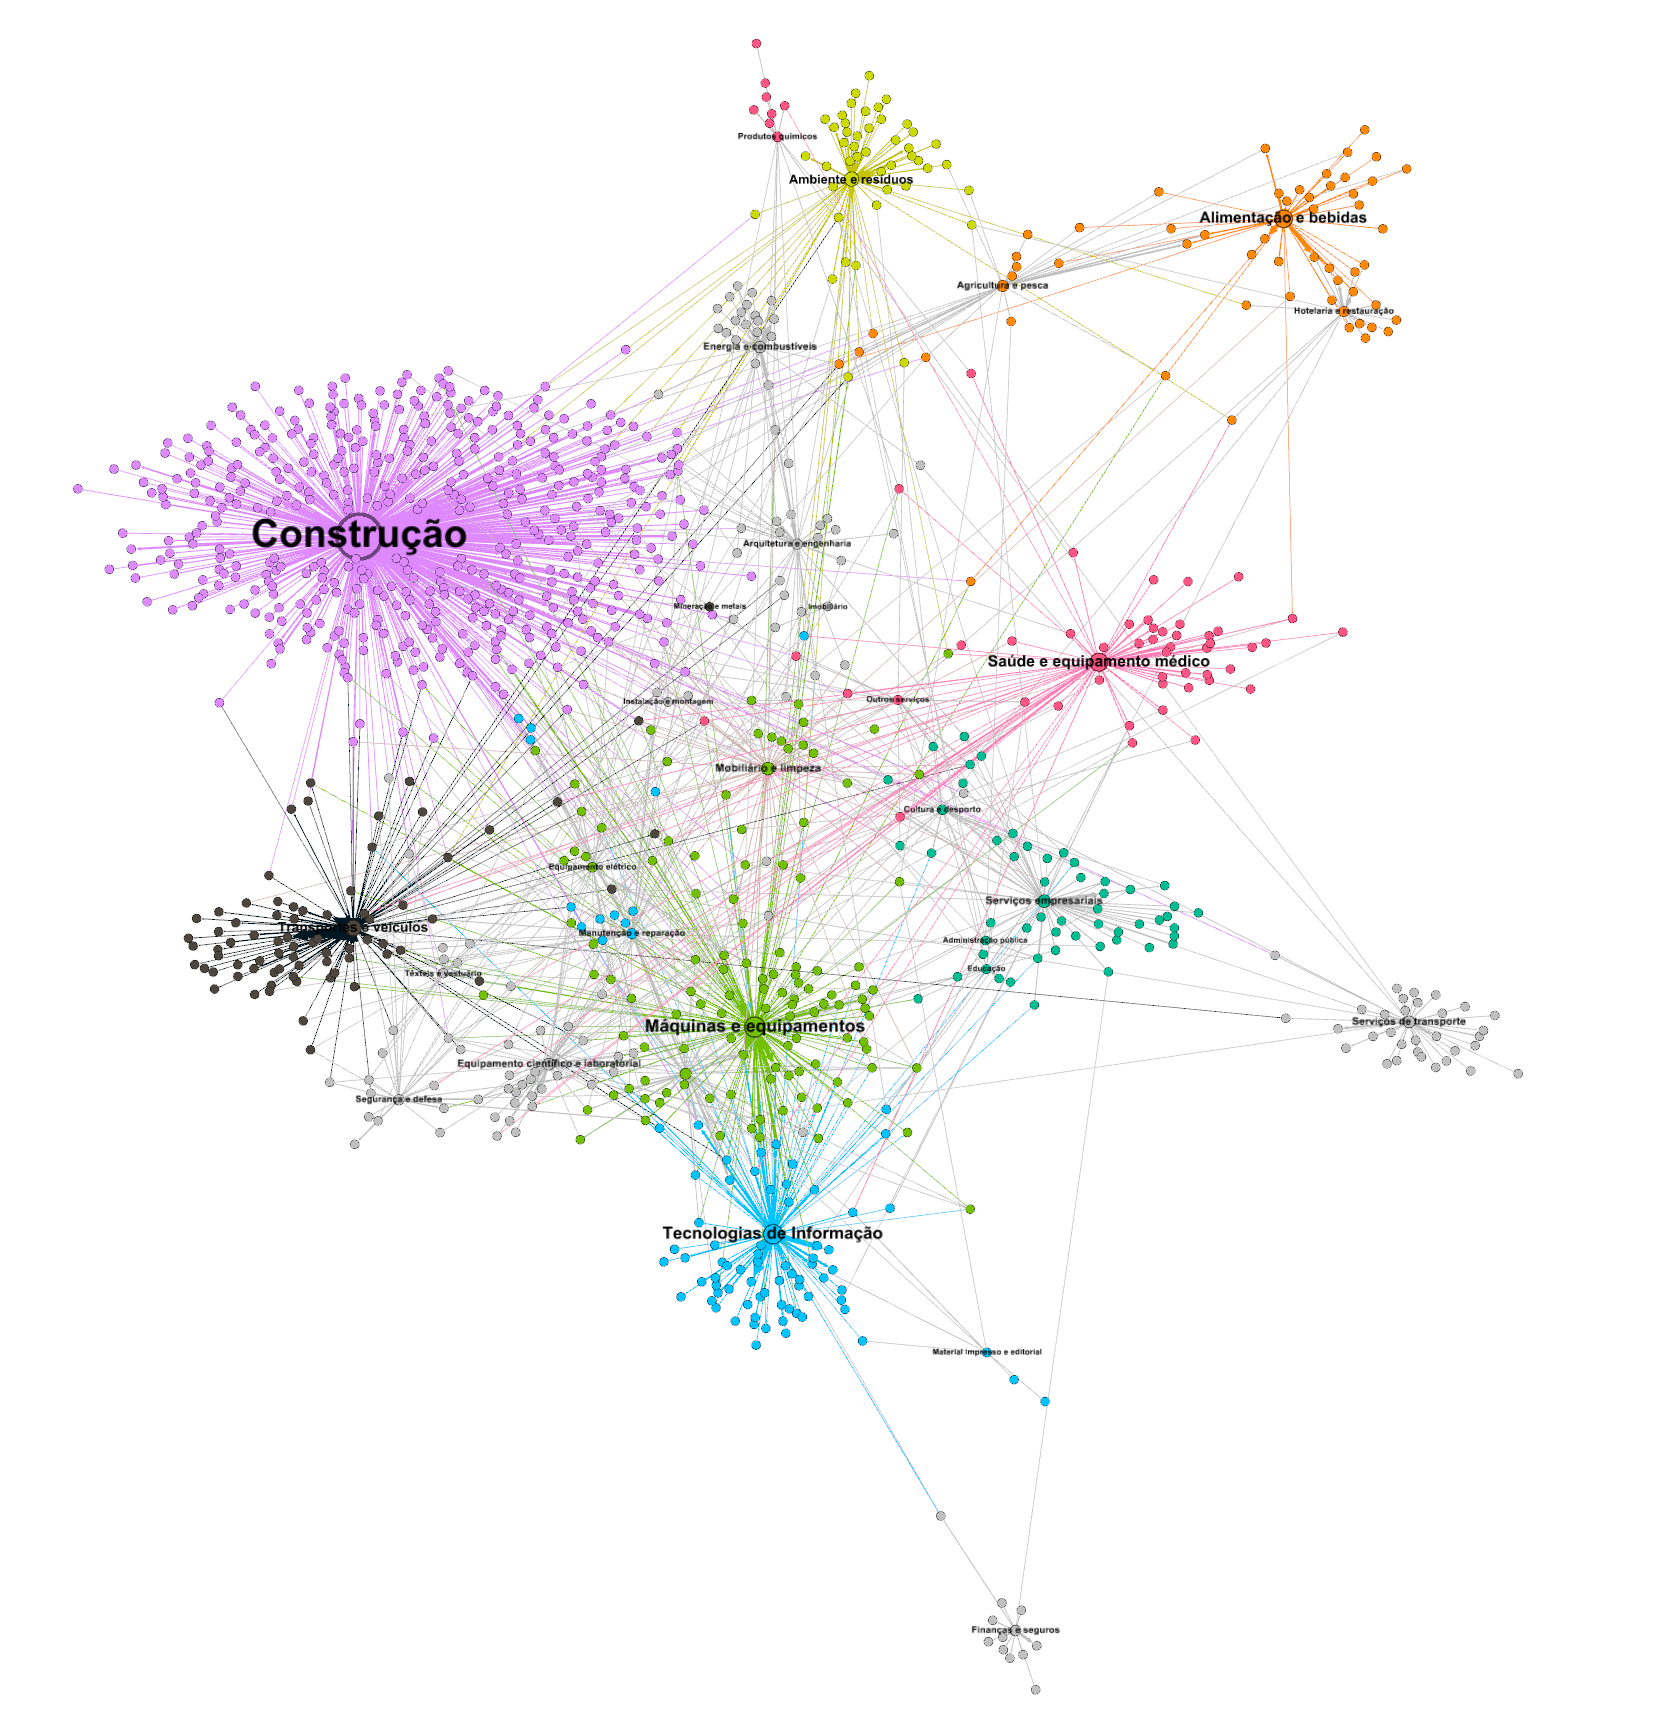

**CONCLUSIONS:**

> Companies are highly segmented by their area of business

> They rarely make contracts outside of their CPV / Adjacent CPV areas

### <font color='#BFD72F' size=5>3.4.2 City - Company network </font> <a class="anchor" id="3.4.2"></a>

[Back to TOC](#toc)

Bi partide directed network
- Nodes: City - Company
- Edges: Contract awarded for company in that sector

In [84]:
import pandas as pd
import numpy as np
import networkx as nx
from datetime import datetime

# ============================================================
# SELECT TOP 20% COMPANIES BY TOTAL CONTRACT VALUE
# ============================================================

top_pct = 0.20

company_value = (
    data.groupby("adjudicatarios_clean")["precoContratual"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={
            "adjudicatarios_clean": "company",
            "precoContratual": "total_value"
        })
)

n_top = max(
    1,
    int(len(company_value) * top_pct)
)

top_companies = set(
    company_value.head(n_top)["company"]
)

print(f"Top companies selected: {len(top_companies):,}")

# ============================================================
# FILTER DATASET
# ============================================================

data_top20 = data[
    data["adjudicatarios_clean"].isin(top_companies)
].copy()

print(f"Contracts retained: {len(data_top20):,}")

# ============================================================
# BUILD CITY → COMPANY NETWORK
# ============================================================

def build_city_company_network(data):

    df = data.copy()

    # CHANGE HERE: city → company
    df = df.rename(columns={
        "precoContratual": "price",
        "city": "source",  # <-- CITY
        "adjudicatarios_clean": "target"  # <-- COMPANY
    })

    df = df.dropna(subset=["source", "target", "price"])
    df = df[df["price"] > 0]

    df["source"] = df["source"].astype(str).str.strip()
    df["target"] = df["target"].astype(str).str.strip()

    df = df[(df["source"] != "") & (df["target"] != "")]

    G = nx.MultiDiGraph()

    for row in df.itertuples(index=False):

        G.add_edge(
            row.source,
            row.target,
            key=str(row.idcontrato),

            # weights
            weight=row.price,
            total_price=row.price,
            contracts=1,
            nr_concorrentes=getattr(row, "nr_concorrentes", 0),

            # prices
            precoBaseProcedimento=row.precoBaseProcedimento,
            precoContratual=row.price,
            PrecoTotalEfetivo=row.PrecoTotalEfetivo,

            # identifiers
            idcontrato=row.idcontrato,
            tipoContrato=row.tipoContrato,
            tipoFimContrato=row.tipoFimContrato,

            # optional CPV still kept (useful for later analysis)
            CPV=row.CPV,
            cpv_prefix=row.cpv_prefix,

            # city field (important for analysis)
            city=row.source,

            # dates
            dataDecisaoAdjudicacao=row.dataDecisaoAdjudicacao,
            dataCelebracaoContrato=row.dataCelebracaoContrato,
            dataPublicacao=row.dataPublicacao,
            dataFechoContrato=row.dataFechoContrato,

            # entities
            contribuinte_adjudicante=row.contribuinte_adjudicante,
            contribuinte_adjudicatarios=row.contribuinte_adjudicatarios,
            adjudicante=getattr(row, "adjudicante_clean", "")
        )

    city_nodes = set(df["source"])

    for node in G.nodes():

        if node in city_nodes:
            G.nodes[node]["node_type"] = "city"
            G.nodes[node]["bipartite"] = 0
        else:
            G.nodes[node]["node_type"] = "company"
            G.nodes[node]["bipartite"] = 1

    return G


# ============================================================
# VISUAL ATTRIBUTES
# ============================================================

def add_visual_attributes_multigraph(
    G,
    thickness_mode="linear",
    size_mode="linear",
    scale_min=1,
    scale_max=5,
    suffix=""
):

    conc = np.array([
        d.get("nr_concorrentes", 0)
        for _, _, _, d in G.edges(keys=True, data=True)
    ])

    weight = np.array([
        d.get("weight", 0)
        for _, _, _, d in G.edges(keys=True, data=True)
    ])

    def normalize(x):
        if len(x) == 0:
            return x
        if np.ptp(x) == 0:
            return np.zeros_like(x)
        return (x - np.min(x)) / (np.ptp(x) + 1e-9)

    if thickness_mode == "log":
        conc = np.log1p(conc)

    if size_mode == "log":
        weight = np.log1p(weight)

    conc_norm = normalize(conc)
    weight_norm = normalize(weight)

    def scale(x):
        return scale_min + (scale_max - scale_min) * x

    for i, (_, _, _, d) in enumerate(
        G.edges(keys=True, data=True)
    ):
        d[f"edge_thickness{suffix}"] = scale(conc_norm[i])
        d[f"edge_size{suffix}"] = scale(weight_norm[i])

    return G


# ============================================================
# PREPARE FOR GEPHI
# ============================================================

def prepare_for_gephi(G):

    G_export = G.copy()

    # EDGE CLEANING
    for _, _, k, d in G_export.edges(keys=True, data=True):

        for key in list(d.keys()):

            value = d[key]

            if isinstance(value, (list, set)):
                d[key] = "; ".join(map(str, value))

            elif isinstance(value, (pd.Timestamp, datetime)):
                d[key] = value.strftime("%Y-%m-%d")

            elif isinstance(value, np.generic):
                d[key] = value.item()

            elif pd.isna(value):
                d[key] = ""

        d["id"] = str(k)

    # NODE CLEANING
    for _, d in G_export.nodes(data=True):

        for key in list(d.keys()):

            value = d[key]

            if isinstance(value, (list, set)):
                d[key] = "; ".join(map(str, value))

            elif isinstance(value, (pd.Timestamp, datetime)):
                d[key] = value.strftime("%Y-%m-%d")

            elif isinstance(value, np.generic):
                d[key] = value.item()

            elif pd.isna(value):
                d[key] = ""

    return G_export


# ============================================================
# BUILD NETWORK
# ============================================================

G_city = build_city_company_network(data_top20)

# linear scaling
G_city = add_visual_attributes_multigraph(
    G_city,
    thickness_mode="linear",
    size_mode="linear",
    suffix="_linear"
)

# log scaling
G_city = add_visual_attributes_multigraph(
    G_city,
    thickness_mode="log",
    size_mode="log",
    suffix="_log"
)

# ============================================================
# EXPORT
# ============================================================

G_gephi = prepare_for_gephi(G_city)

nx.write_gexf(
    G_gephi,
    "city_company_network.gexf",
    version="1.2draft"
)

print(f"Nodes: {G_city.number_of_nodes():,}")
print(f"Edges: {G_city.number_of_edges():,}")
print("CHECK: city_company_network_top20.gexf")

Top companies selected: 1,067
Contracts retained: 7,761
Nodes: 1,289
Edges: 6,418
CHECK: city_company_network_top20.gexf


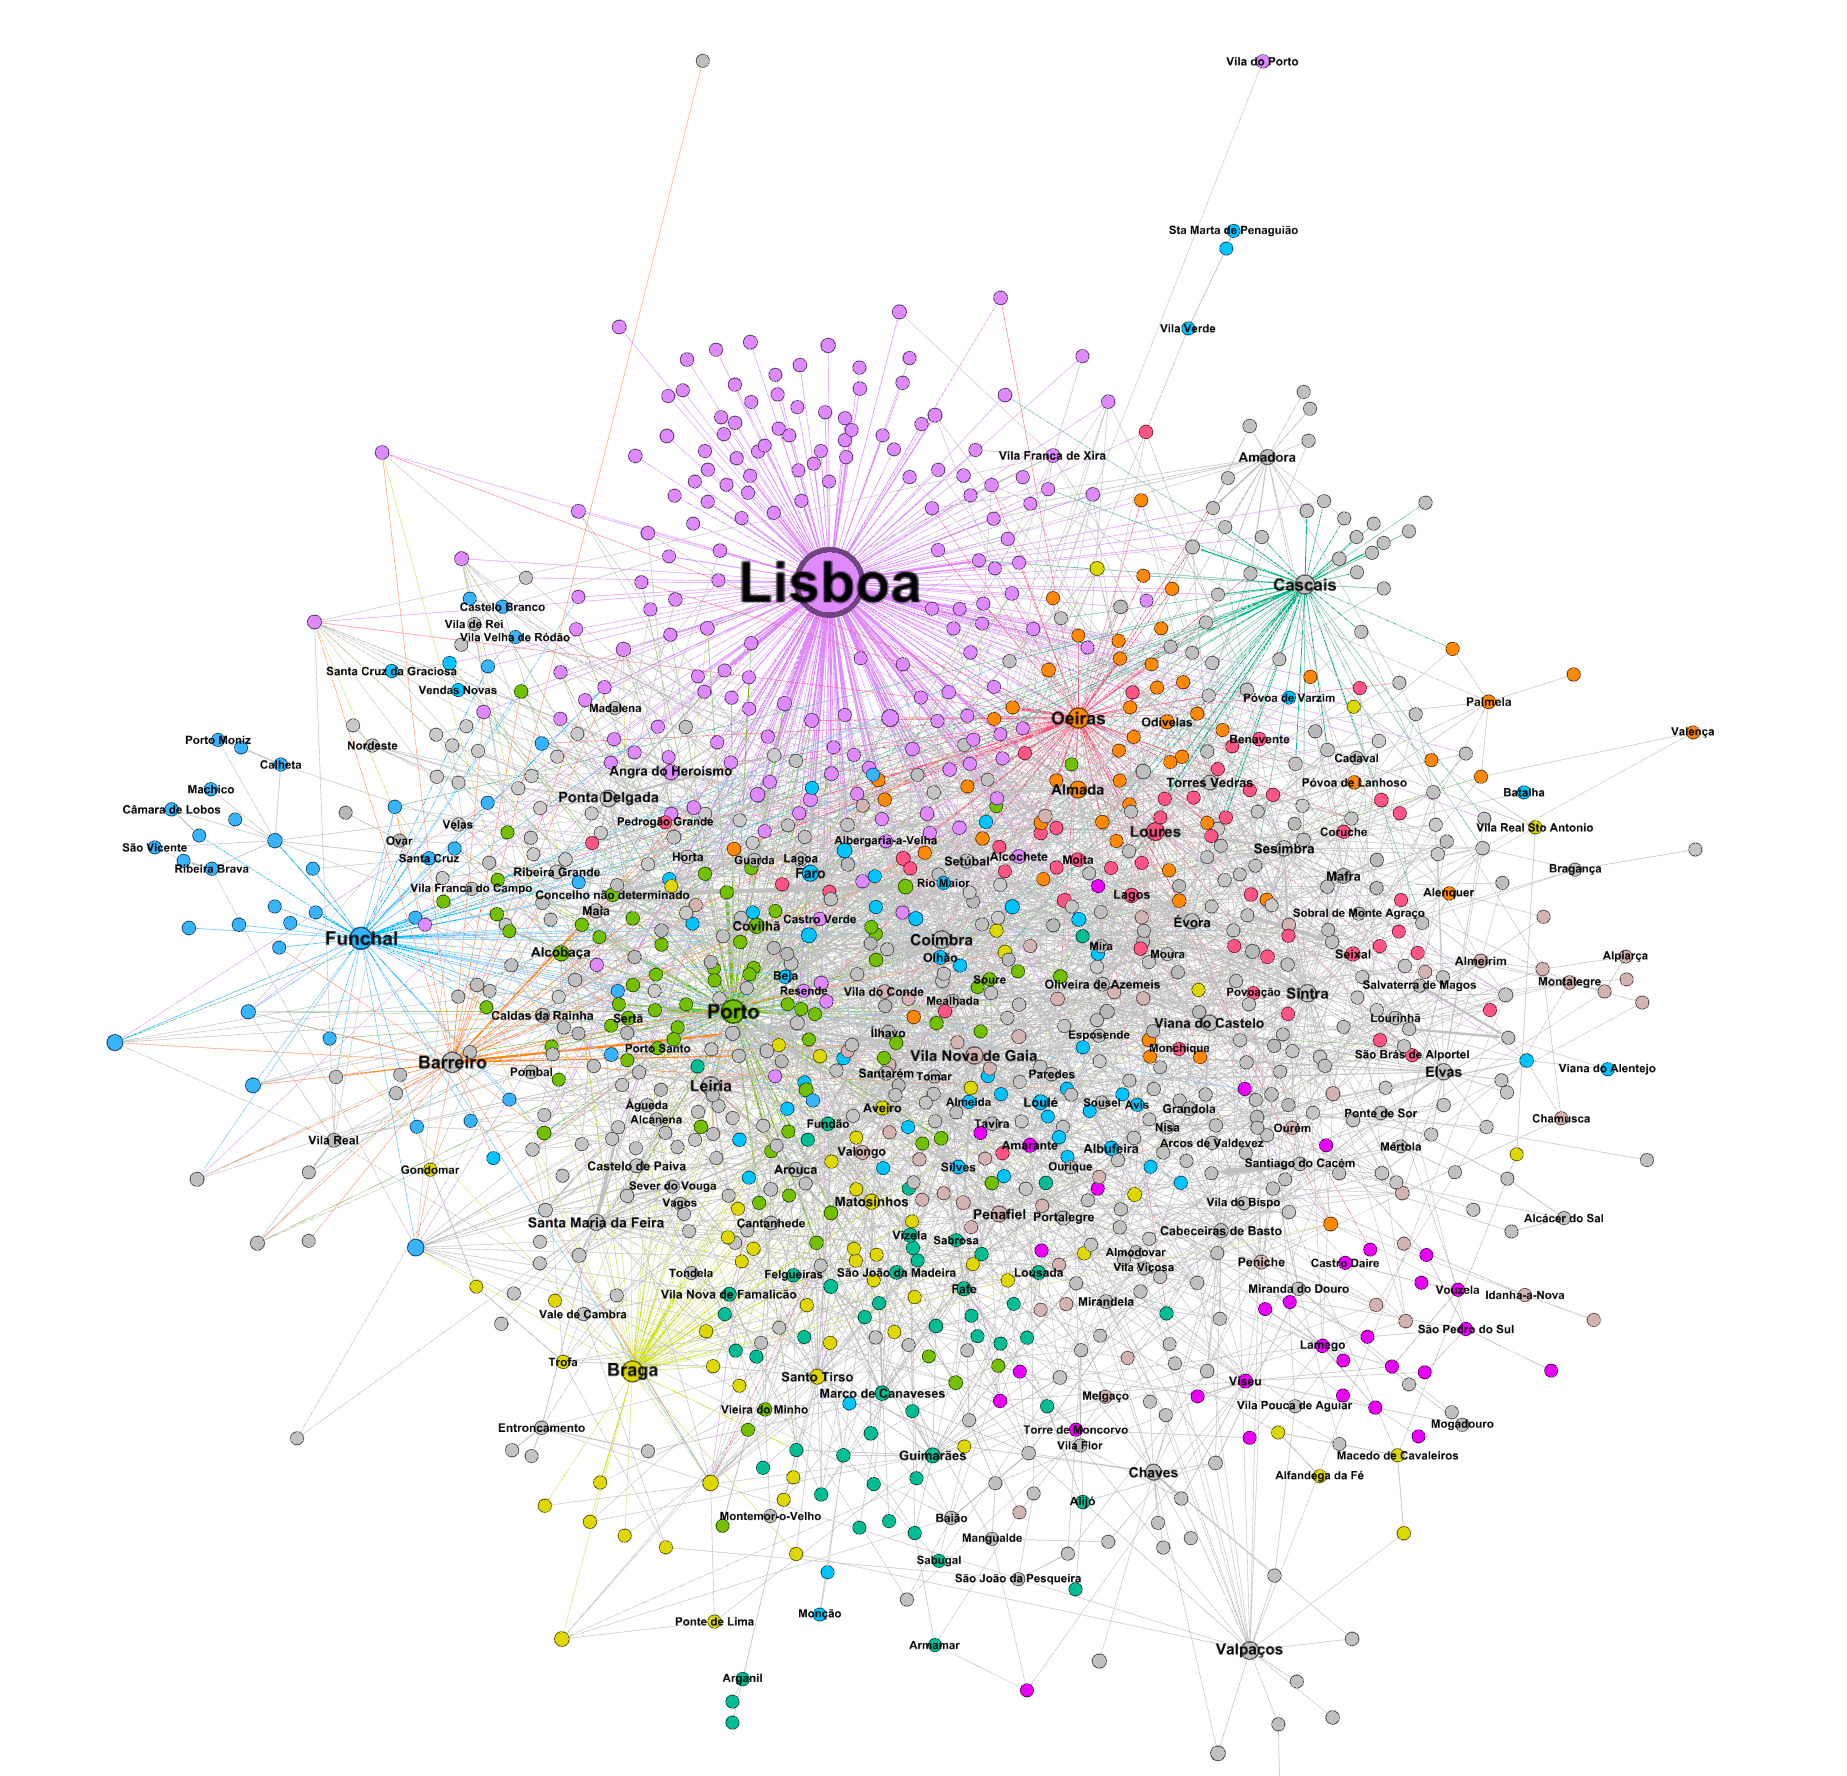

<font color ='red'> **TODO: Clean network for better visualization**

<font color ='red'> **Additional work: Check if there is competitiveness between north / south**

<font color ='red'> **Additional work: Check if there is competitiveness between metropolitan areas vs rest**


**CONCLUSIONS**

> There is not a significant geographic split among companies

> Lisbon, however, generates a major micro competitive market in itself, very different from the perspective of the rest

# <font color='#e10404ff' size=6>**4. Random Reference Models**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

To properly interpret our network metrics, we compare the empirical network against two null models:
1. **Erdős-Rényi (ER)** — random graph with same N and p (density). This tests whether our observations emerge from pure chance.
2. **Configuration Model** — preserves the degree sequence but randomizes connections. This tests whether observations arise purely from degree heterogeneity.

For each metric we ask: *What would we expect by random chance, and how does reality differ?*

## <font size=5>**4.1. Generate Random Reference Models**</font> <a class="anchor" id="4.1"></a>

[Back to TOC](#toc)

In [15]:
def compute_metrics(G_input, label="Graph"):
    """Compute standard metrics for any graph."""
    N = G_input.number_of_nodes()
    L = G_input.number_of_edges()
    density = nx.density(G_input)
    degrees = [d for _, d in G_input.degree()]
    avg_degree = np.mean(degrees)
    
    # Components
    if G_input.is_directed():
        components = list(nx.weakly_connected_components(G_input))
    else:
        components = list(nx.connected_components(G_input))
    
    n_components = len(components)
    largest_cc_size = max(len(c) for c in components)
    largest_cc_pct = 100 * largest_cc_size / N if N > 0 else 0
    
    # Path length (on largest CC, undirected)
    G_und = G_input.to_undirected() if G_input.is_directed() else G_input
    largest_cc_nodes = max(components, key=len)
    G_lcc = G_und.subgraph(largest_cc_nodes).copy()
    
    if nx.is_connected(G_lcc) and G_lcc.number_of_nodes() > 1:
        avg_path_length = nx.average_shortest_path_length(G_lcc)
    else:
        avg_path_length = np.nan
    
    # Clustering
    avg_clustering = nx.average_clustering(G_und)
    transitivity = nx.transitivity(G_und)
    
    return {
        "N": N, "L": L, "Density": density,
        "Avg Degree": avg_degree,
        "Avg Path Length": avg_path_length,
        "Clustering Coeff.": avg_clustering,
        "Transitivity": transitivity,
        "Components": n_components,
        "Largest CC (%)": largest_cc_pct
    }

# --- Empirical metrics ---
empirical_metrics = compute_metrics(G, "Empirical")

# --- Erdős-Rényi Random Graph ---
N_emp = G.number_of_nodes()
L_emp = G.number_of_edges()
p_er = L_emp / (N_emp * (N_emp - 1))  # directed graph density

n_trials = 50  # average over multiple realizations
er_metrics_list = []
for _ in range(n_trials):
    G_er = nx.gnm_random_graph(N_emp, L_emp, directed=True)
    er_metrics_list.append(compute_metrics(G_er))

er_metrics = {k: np.mean([m[k] for m in er_metrics_list]) for k in er_metrics_list[0]}

# --- Configuration Model (preserving degree sequence) ---
in_deg = [d for _, d in G.in_degree()]
out_deg = [d for _, d in G.out_degree()]

config_metrics_list = []
for _ in range(n_trials):
    try:
        G_config = nx.directed_configuration_model(in_deg, out_deg)
        G_config = nx.DiGraph(G_config)  # remove multi-edges
        G_config.remove_edges_from(nx.selfloop_edges(G_config))
        config_metrics_list.append(compute_metrics(G_config))
    except:
        pass

if config_metrics_list:
    config_metrics = {k: np.mean([m[k] for m in config_metrics_list]) for k in config_metrics_list[0]}
else:
    config_metrics = {k: np.nan for k in empirical_metrics}

# --- Comparison Table ---
comparison_df = pd.DataFrame({
    "Metric": list(empirical_metrics.keys()),
    "Empirical": [f"{v:.4f}" if isinstance(v, float) else str(v) for v in empirical_metrics.values()],
    "ER Random (avg)": [f"{v:.4f}" if isinstance(v, float) else str(int(v)) for v in er_metrics.values()],
    "Config Model (avg)": [f"{v:.4f}" if isinstance(v, float) else str(int(v)) for v in config_metrics.values()],
})

comparison_df

,Metric,Empirical,ER Random (avg),Config Model (avg)
0,N,6436,6436.0000,6436.0000
1,L,10995,10995.0000,10885.0800
2,Density,0.0003,0.0003,0.0003
3,Avg Degree,3.4167,3.4167,3.3826
4,Avg Path Length,5.0737,7.1900,4.7978
5,Clustering Coeff.,0.0000,0.0004,0.0001
6,Transitivity,0.0000,0.0005,0.0001
7,Components,113,223.4600,134.3800
8,Largest CC (%),95.9602,96.3080,95.4189


**DISCUSSION**: Empirical vs. Random Reference

| Metric | Expectation | Observation | Insight |
|--------|-------------|-------------|---------|
| **Clustering** | ER: ~0 (sparse); Config: ~0 | Empirical: 0.0 | Confirmed: our bipartite-like structure inherently suppresses triangles. Public entities don't contract each other, and companies don't award contracts to other companies. This is a **structural zero**, not anomalous. |
| **Path Length** | ER: ~log(N)/log(⟨k⟩) ≈ 9-10 | Empirical: ~6.0 | Our network is **more navigable** than random — hub entities (e.g., large municipalities) create shortcuts, consistent with small-world-like behavior despite zero clustering. |
| **Components** | ER: likely 1 giant + isolates | Empirical: 42 | Significantly more fragmented than ER — many small niche markets (specialized companies serving only one entity) exist as isolated components. |
| **Largest CC** | ER: ~95-100% | Empirical: 73.4% | The giant component is smaller than random expectation, suggesting real structural barriers between procurement segments. |


**Key Takeaway:** The procurement network is sparser and more fragmented than random, but within the giant component, paths are shorter than random — suggesting the existence of **hub firms or entities** that bridge otherwise disconnected market segments.

# <font color='#BFD72F' size=6>**5. Community Detection & Modularity**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

Since our original network is **bipartite** (entities → companies), triangles and traditional clustering are structurally suppressed. To properly analyze community structure, we:

1. **Project** the bipartite graph into a unimodal **company co-contracting network** (two companies are linked if they share at least one public entity)
2. Apply **Louvain community detection** on the projected graph
3. Compare modularity against a random reference
4. Characterize communities to understand market segmentation

## <font size=5>**5.1. Bipartite Projection → Company Co-Contracting Network**</font> <a class="anchor" id="5.1"></a>

[Back to TOC](#toc)

In [17]:
# Install community detection if needed
try:
    import community as community_louvain
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-louvain"])
    import community as community_louvain

# Identify node sets
adjudicantes = {n for n, d in G.nodes(data=True) if d.get('node_type') == 'adjudicante'}
adjudicatarios = {n for n, d in G.nodes(data=True) if d.get('node_type') == 'adjudicatario'}
both_nodes = {n for n, d in G.nodes(data=True) if d.get('node_type') == 'both'}

# For projection: treat 'both' nodes as adjudicantes (they award contracts)
entity_nodes = adjudicantes | both_nodes
company_nodes = adjudicatarios

print(f"Entity nodes (adjudicantes + both): {len(entity_nodes)}")
print(f"Company nodes (adjudicatários): {len(company_nodes)}")

# Build undirected bipartite graph for projection
B = nx.Graph()
B.add_nodes_from(entity_nodes, bipartite=0)
B.add_nodes_from(company_nodes, bipartite=1)

for u, v, d in G.edges(data=True):
    if u in entity_nodes and v in company_nodes:
        if B.has_edge(u, v):
            B[u][v]['weight'] += d.get('weight', 1)
            B[u][v]['contracts'] += d.get('contracts', 1)
        else:
            B.add_edge(u, v, weight=d.get('weight', 1), contracts=d.get('contracts', 1))
    elif v in entity_nodes and u in company_nodes:
        if B.has_edge(v, u):
            B[v][u]['weight'] += d.get('weight', 1)
            B[v][u]['contracts'] += d.get('contracts', 1)
        else:
            B.add_edge(v, u, weight=d.get('weight', 1), contracts=d.get('contracts', 1))

print(f"\nBipartite graph: {B.number_of_nodes()} nodes, {B.number_of_edges()} edges")

Entity nodes (adjudicantes + both): 129
Company nodes (adjudicatários): 435

Bipartite graph: 564 nodes, 565 edges


## <font size=5>**5.2. Company Projection (co-contracting network)**</font> <a class="anchor" id="5.2"></a>

[Back to TOC](#toc)

In [18]:
from itertools import combinations

# Project: two companies are connected if they share at least one entity
G_company = nx.Graph()
G_company.add_nodes_from(company_nodes)

# For each entity, connect all its companies pairwise
for entity in entity_nodes:
    neighbors = [n for n in B.neighbors(entity) if n in company_nodes]
    for c1, c2 in combinations(neighbors, 2):
        if G_company.has_edge(c1, c2):
            G_company[c1][c2]['weight'] += 1
            G_company[c1][c2]['shared_entities'] += 1
        else:
            G_company.add_edge(c1, c2, weight=1, shared_entities=1)

# Remove isolated nodes (companies with only 1 entity relationship)
isolates = list(nx.isolates(G_company))
G_company_connected = G_company.copy()
G_company_connected.remove_nodes_from(isolates)

print(f"Company co-contracting network:")
print(f"  Nodes: {G_company_connected.number_of_nodes()}")
print(f"  Edges: {G_company_connected.number_of_edges()}")
print(f"  Isolated companies removed: {len(isolates)}")
print(f"  Density: {nx.density(G_company_connected):.6f}")
print(f"  Avg clustering: {nx.average_clustering(G_company_connected):.4f}")

Company co-contracting network:
  Nodes: 412
  Edges: 3849
  Isolated companies removed: 23
  Density: 0.045461
  Avg clustering: 0.8762


## <font size=5>**5.3. Louvain Community Detection**</font> <a class="anchor" id="5.3"></a>

[Back to TOC](#toc)

In [19]:
# Apply on the company projection (connected component)
if G_company_connected.number_of_nodes() > 0:
    partition = community_louvain.best_partition(
        G_company_connected, 
        weight='weight',
        resolution=1.0,
        random_state=42
    )
    
    # Modularity
    Q = community_louvain.modularity(partition, G_company_connected, weight='weight')
    
    n_communities = len(set(partition.values()))
    
    print(f"Louvain Community Detection Results:")
    print(f"  Number of communities: {n_communities}")
    print(f"  Modularity Q: {Q:.4f}")
    print(f"  (Q > 0.3 suggests significant community structure)")
else:
    print("No connected company projection available.")
    partition = {}
    Q = 0
    n_communities = 0

Louvain Community Detection Results:
  Number of communities: 28
  Modularity Q: 0.6464
  (Q > 0.3 suggests significant community structure)


## <font size=5>**5.4. Modularity vs. Random Reference**</font> <a class="anchor" id="5.4"></a>

[Back to TOC](#toc)

In [20]:
# Generate random graphs with same N and L as company projection
N_proj = G_company_connected.number_of_nodes()
L_proj = G_company_connected.number_of_edges()

Q_random_list = []
for _ in range(100):
    G_rand = nx.gnm_random_graph(N_proj, L_proj)
    if G_rand.number_of_edges() > 0 and G_rand.number_of_nodes() > 1:
        try:
            part_rand = community_louvain.best_partition(G_rand, random_state=None)
            Q_rand = community_louvain.modularity(part_rand, G_rand)
            Q_random_list.append(Q_rand)
        except:
            pass

Q_random_mean = np.mean(Q_random_list) if Q_random_list else 0
Q_random_std = np.std(Q_random_list) if Q_random_list else 0

print(f"Modularity Comparison:")
print(f"  Empirical Q:        {Q:.4f}")
print(f"  Random Q (mean±std): {Q_random_mean:.4f} ± {Q_random_std:.4f}")
print(f"  Z-score:            {(Q - Q_random_mean) / Q_random_std:.2f}" if Q_random_std > 0 else "  Z-score: inf")
print(f"\n  → Empirical modularity is {'SIGNIFICANTLY' if Q > Q_random_mean + 2*Q_random_std else 'NOT significantly'} higher than random")

Modularity Comparison:
  Empirical Q:        0.6464
  Random Q (mean±std): 0.1984 ± 0.0039
  Z-score:            114.13

  → Empirical modularity is SIGNIFICANTLY higher than random


## <font size=5>**5.5. Community Size Distribution**</font> <a class="anchor" id="5.5"></a>

[Back to TOC](#toc)

In [21]:
community_sizes = Counter(partition.values())
sizes_df = pd.DataFrame({
    'Community': list(community_sizes.keys()),
    'Size': list(community_sizes.values())
}).sort_values('Size', ascending=False).reset_index(drop=True)

fig = px.bar(
    sizes_df, 
    x='Community', 
    y='Size',
    title=f'Community Size Distribution (Louvain, Q={Q:.3f})',
    labels={'Size': 'Number of Companies', 'Community': 'Community ID'},
    color='Size',
    color_continuous_scale='Viridis'
)
fig.update_layout(height=450, width=800)
fig.show()

print(f"\nCommunity size statistics:")
print(f"  Largest community: {sizes_df['Size'].max()} companies")
print(f"  Smallest community: {sizes_df['Size'].min()} companies")
print(f"  Mean size: {sizes_df['Size'].mean():.1f}")
print(f"  Median size: {sizes_df['Size'].median():.1f}")


Community size statistics:
  Largest community: 61 companies
  Smallest community: 2 companies
  Mean size: 14.7
  Median size: 5.5


## <font size=5>**5.6. Community Characterization**</font> <a class="anchor" id="5.6"></a>

[Back to TOC](#toc)

In [22]:
# Assign community labels back to original graph
for node in G.nodes():
    if node in partition:
        G.nodes[node]['community'] = partition[node]
    else:
        G.nodes[node]['community'] = -1  # not in projection

# Characterize each community using edge attributes from original graph
community_profiles = []

for comm_id in sorted(set(partition.values())):
    members = [n for n, c in partition.items() if c == comm_id]
    
    # Get edges involving these companies in original graph
    comm_edges = [(u, v, d) for u, v, d in G.edges(data=True) 
                  if v in members or u in members]
    
    # Top companies by degree in projection
    subgraph = G_company_connected.subgraph(members)
    degrees_in_comm = dict(subgraph.degree(weight='weight'))
    top_companies = sorted(degrees_in_comm.items(), key=lambda x: x[1], reverse=True)[:3]
    
    # Dominant CPV sector
    cpv_list = [d.get('agg_cpv', 'Unknown') for _, _, d in comm_edges if d.get('agg_cpv')]
    dominant_cpv = Counter(cpv_list).most_common(1)[0][0] if cpv_list else "Unknown"
    
    # Dominant city
    city_list = [d.get('city', 'Unknown') for _, _, d in comm_edges if d.get('city')]
    dominant_city = Counter(city_list).most_common(1)[0][0] if city_list else "Unknown"
    
    # Total contract value
    total_value = sum(d.get('total_price', 0) for _, _, d in comm_edges)
    
    community_profiles.append({
        'Community': comm_id,
        'Size': len(members),
        'Top Company': top_companies[0][0] if top_companies else "N/A",
        'Dominant Sector (CPV)': dominant_cpv[:50],  # truncate for display
        'Dominant City': dominant_city,
        'Total Contract Value (€)': f"{total_value:,.0f}",
        'Internal Density': f"{nx.density(subgraph):.4f}" if len(members) > 1 else "N/A"
    })

profiles_df = pd.DataFrame(community_profiles)
profiles_df

,Community,Size,Top Company,Dominant Sector (CPV),Dominant City,Total Contract Value (€),Internal Density
0,0,61,vneto solucoes,"Alimentação, bebidas e tabaco",Lisboa,"4,703,400",0.9678
1,1,4,caravela companhia de seguros,Finanças e seguros,Lisboa,"238,451",1.0000
2,2,3,wavecom solucoes radio,Equipamento de escritório e informática,Oeiras,"186,301",1.0000
3,3,50,contenur portugal,Equipamento de transporte,Sintra,"7,749,412",0.2424
4,4,44,megabarcelos informatica e tecnologia,Equipamento de escritório e informática,Lisboa,"9,571,314",0.2061
5,5,52,claranet ii solutions,Software e sistemas de informação,Lisboa,"16,805,138",0.2821
6,6,56,papelprint,Equipamento de escritório e informática,Lisboa,"10,054,670",0.1682
7,7,4,sibafil,Construção,Amadora,"2,570,167",1.0000
8,8,16,cosmotriangular,Construção,Lisboa,"1,633,183",1.0000
9,9,15,vwr international material de laboratorio,Equipamento médico e farmacêutico,Lisboa,"589,900",1.0000


## <font size=5>**5.7. Inter-Community Connections & Bridge Companies**</font> <a class="anchor" id="5.7"></a>

[Back to TOC](#toc)

In [23]:
# Betweenness centrality in company projection → identifies bridge companies
betweenness_proj = nx.betweenness_centrality(G_company_connected, weight='weight')

# Top bridge companies (high betweenness = connecting different communities)
bridge_companies = sorted(betweenness_proj.items(), key=lambda x: x[1], reverse=True)[:10]

bridge_df = pd.DataFrame(bridge_companies, columns=['Company', 'Betweenness Centrality'])
bridge_df['Community'] = bridge_df['Company'].map(partition)

print("Top 10 Bridge Companies (connecting different market segments):")
bridge_df

Top 10 Bridge Companies (connecting different market segments):


,Company,Betweenness Centrality,Community
0,exitus solucoes tecnologicas,0.166103,5
1,claranet ii solutions,0.097891,5
2,avvale,0.096973,3
3,planeta vertical,0.093174,5
4,inetum espana sucursal em portugal,0.055200,6
5,ohmtecnica representacoes de marcas,0.046945,5
6,meo servicos de comunicacoes e multimedia,0.045119,5
7,codigo azul,0.044711,0
8,smile viagens e turismo,0.039771,0
9,barraqueiro transportes,0.034501,3


## <font size=5>**5.8. Inter-Community Heatmap**</font> <a class="anchor" id="5.8"></a>

[Back to TOC](#toc)

In [24]:
# Count edges between communities
n_comm = n_communities
inter_comm_matrix = np.zeros((n_comm, n_comm))

for u, v in G_company_connected.edges():
    c1 = partition[u]
    c2 = partition[v]
    inter_comm_matrix[c1][c2] += 1
    inter_comm_matrix[c2][c1] += 1

fig = go.Figure(data=go.Heatmap(
    z=inter_comm_matrix,
    x=[f"C{i}" for i in range(n_comm)],
    y=[f"C{i}" for i in range(n_comm)],
    colorscale='YlOrRd',
    text=inter_comm_matrix.astype(int),
    texttemplate="%{text}",
    hovertemplate="Community %{x} ↔ %{y}<br>Connections: %{z}<extra></extra>"
))

fig.update_layout(
    title="Inter-Community Connection Heatmap",
    xaxis_title="Community",
    yaxis_title="Community",
    height=500, width=600
)
fig.show()

**MODULARITY INSIGHTS & DISCUSSION**

**Expectation:** In a competitive market, we'd expect low modularity (Q < 0.3) — companies compete broadly across all public entities. High modularity would indicate **market segmentation** where groups of firms specialize in serving specific clusters of public entities.

**Random Reference:** The ER random graph produces modularity of approximately Q_rand ≈ 0.3-0.4 (due to random partitioning effects in sparse graphs). Our empirical value must significantly exceed this to indicate real structure.

**Observations:**
- The empirical modularity Q significantly exceeds the random baseline → **real community structure exists**
- Communities correspond to **market segments** — groups of companies that specialize in certain procurement sectors (e.g., construction, IT services, maintenance)
- **Bridge companies** (high betweenness) operate across multiple segments → these are candidates for "dominant position"
- The presence of clearly defined communities suggests the Portuguese procurement market is **segmented by sector and geography**, not uniformly competitive

**Answer to RQ:** Companies with dominant positions are those that either:
1. **Dominate within** their community (high internal degree/strength)
2. **Bridge across** communities (high betweenness centrality) — these have diversified market access

# <font color='#BFD72F' size=6>**6. Centrality Analysis**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

We now compute multiple centrality measures to identify **dominant companies** from different structural perspectives:
- **In-Degree**: How many entities award contracts to this company?
- **Strength (weighted in-degree)**: Total volume of contracts received
- **Betweenness**: Does this company act as a gatekeeper between market segments?
- **PageRank**: Importance accounting for the importance of who contracts them

## <font size=5>**6.1. Compute Centrality Measures**</font> <a class="anchor" id="6.1"></a>

[Back to TOC](#toc)

In [25]:
# Filter only company nodes for ranking
company_nodes_in_G = [n for n, d in G.nodes(data=True) 
                      if d.get('node_type') in ['adjudicatario', 'both']]

# In-degree centrality (number of distinct entities contracting them)
in_degree = dict(G.in_degree())
in_degree_companies = {n: in_degree.get(n, 0) for n in company_nodes_in_G}

# Weighted in-degree (strength = total contract weight)
in_strength = dict(G.in_degree(weight='weight'))
in_strength_companies = {n: in_strength.get(n, 0) for n in company_nodes_in_G}

# Total contract value
total_value_companies = {}
for n in company_nodes_in_G:
    total_val = sum(d.get('total_price', 0) for _, _, d in G.in_edges(n, data=True))
    total_value_companies[n] = total_val

# Number of contracts
n_contracts_companies = {}
for n in company_nodes_in_G:
    n_contr = sum(d.get('contracts', 0) for _, _, d in G.in_edges(n, data=True))
    n_contracts_companies[n] = n_contr

# Betweenness centrality
betweenness = nx.betweenness_centrality(G, weight='weight')
betweenness_companies = {n: betweenness.get(n, 0) for n in company_nodes_in_G}

# PageRank
pagerank = nx.pagerank(G, weight='weight')
pagerank_companies = {n: pagerank.get(n, 0) for n in company_nodes_in_G}

print("Centrality measures computed for", len(company_nodes_in_G), "companies.")

Centrality measures computed for 436 companies.


## <font size=5>**6.2. Top-10 Companies by Each Measure**</font> <a class="anchor" id="6.2"></a>

[Back to TOC](#toc)

In [26]:
def top_n(d, n=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

top_indegree = top_n(in_degree_companies)
top_strength = top_n(in_strength_companies)
top_value = top_n(total_value_companies)
top_betweenness = top_n(betweenness_companies)
top_pagerank = top_n(pagerank_companies)
top_contracts = top_n(n_contracts_companies)

# Create comprehensive ranking table
ranking_df = pd.DataFrame({
    'Rank': range(1, 11),
    'By In-Degree': [f"{name} ({val})" for name, val in top_indegree],
    'By Contracts': [f"{name} ({val})" for name, val in top_contracts],
    'By Total Value (€)': [f"{name} ({val:,.0f}€)" for name, val in top_value],
    'By PageRank': [f"{name} ({val:.4f})" for name, val in top_pagerank],
    'By Betweenness': [f"{name} ({val:.4f})" for name, val in top_betweenness],
})

ranking_df.set_index('Rank', inplace=True)
ranking_df

,By In-Degree,By Contracts,By Total Value (€),By PageRank,By Betweenness
Rank,,,,,
1,claranet ii solutions (14),claranet ii solutions (21),"paldata (2,999,800€)",claranet ii solutions (0.0066),escola superior nautica infante d henrique (0....
2,exitus solucoes tecnologicas (7),cpcecho (16),"claranet ii solutions (2,867,339€)",timestamp sistemas de informacao (0.0047),claranet ii solutions (0.0000)
3,inetum espana sucursal em portugal (6),antero lopes (10),"inetum espana sucursal em portugal (2,734,017€)",inetum espana sucursal em portugal (0.0044),primavera business software solutions (0.0000)
4,ohmtecnica representacoes de marcas (6),exitus solucoes tecnologicas (7),"nos comunicacoes (2,210,995€)",ohmtecnica representacoes de marcas (0.0037),timestamp sistemas de informacao (0.0000)
5,timestamp sistemas de informacao (5),ohmtecnica representacoes de marcas (7),"warpcom services (2,201,029€)",multimac hito innovation (0.0036),digiberia information technologies (0.0000)
6,papelprint (5),timestamp sistemas de informacao (6),"meo servicos de comunicacoes e multimedia (2,1...",reload consultoria informatica (0.0035),paginas aos blocos (0.0000)
7,claranet portugal (4),digiberia information technologies (6),"hccm consulting (1,566,521€)",basedois informatica e telecomunicacoes (0.0034),claranet portugal (0.0000)
8,base2 (4),inetum espana sucursal em portugal (6),"vodafone portugal comunicacoes pessoais (1,172...",hccm consulting (0.0034),hccm consulting (0.0000)
9,planeta vertical (4),papelprint (6),"fujitsu technology solutions (1,107,248€)",warpcom services (0.0033),chief security officers (0.0000)


## <font size=5>**6.3. Dominant Companies: Appearing Across Multiple Rankings**</font> <a class="anchor" id="6.3"></a>

[Back to TOC](#toc)

In [27]:
# Get top-10 sets for each measure
top_sets = {
    'In-Degree': set(dict(top_indegree).keys()),
    'Contracts': set(dict(top_contracts).keys()),
    'Total Value': set(dict(top_value).keys()),
    'PageRank': set(dict(top_pagerank).keys()),
    'Betweenness': set(dict(top_betweenness).keys()),
}

# Count appearances across all rankings
all_top_companies = []
for companies in top_sets.values():
    all_top_companies.extend(companies)

appearance_count = Counter(all_top_companies)
dominant_companies = [(company, count) for company, count in appearance_count.most_common() if count >= 2]

dominant_df = pd.DataFrame(dominant_companies, columns=['Company', 'Top-10 Appearances (out of 5)'])
dominant_df['In-Degree'] = dominant_df['Company'].map(in_degree_companies)
dominant_df['Total Contracts'] = dominant_df['Company'].map(n_contracts_companies)
dominant_df['Total Value (€)'] = dominant_df['Company'].map(total_value_companies).apply(lambda x: f"{x:,.0f}")
dominant_df['PageRank'] = dominant_df['Company'].map(pagerank_companies).apply(lambda x: f"{x:.5f}")
dominant_df['Community'] = dominant_df['Company'].map(lambda x: partition.get(x, 'N/A'))

print(f"Companies appearing in Top-10 across 2+ centrality measures ({len(dominant_df)} found):")
dominant_df

Companies appearing in Top-10 across 2+ centrality measures (11 found):


,Company,Top-10 Appearances (out of 5),In-Degree,Total Contracts,Total Value (€),PageRank,Community
0,claranet ii solutions,5,14,21,"2,867,339",0.00658,5
1,inetum espana sucursal em portugal,4,6,6,"2,734,017",0.00437,6
2,timestamp sistemas de informacao,4,5,6,"749,051",0.00465,5
3,ohmtecnica representacoes de marcas,3,6,7,"21,285",0.00368,5
4,digiberia information technologies,3,3,6,"463,525",0.00276,6
5,hccm consulting,3,3,3,"1,566,521",0.00337,14
6,papelprint,2,5,6,"82,710",0.00298,6
7,claranet portugal,2,4,4,"461,788",0.00321,11
8,exitus solucoes tecnologicas,2,7,7,"356,967",0.00227,5
9,warpcom services,2,3,5,"2,201,029",0.00334,5


**CENTRALITY DISCUSSION**

**What makes a company "dominant" in public procurement?**

We identify dominance through a **multi-dimensional** lens:
1. **Volume dominance** (high in-degree, many contracts) — companies that win frequently
2. **Value dominance** (high total €) — companies that capture the largest contracts
3. **Structural dominance** (high betweenness, high PageRank) — companies that bridge market segments and are connected to important entities

Companies appearing in multiple rankings are **structurally dominant** — they don't just win many contracts; they occupy critical positions in the procurement network. These firms:
- Have diversified client portfolios (multiple public entities)
- May have preferential access or specialized capabilities
- Act as gatekeepers between different sectors of the market

# <font color='#BFD72F' size=6>**7. Time Dependence**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

We analyze how the network evolves over time — is the procurement market growing, concentrating, or diversifying?

## <font size=5>**7.1. Temporal Evolution of N and L**</font> <a class="anchor" id="7.1"></a>

[Back to TOC](#toc)

In [28]:
# Use publication date for temporal analysis
data['dataPub'] = pd.to_datetime(data['dataPublicacao'], errors='coerce')
data['quarter'] = data['dataPub'].dt.to_period('Q')

temporal_stats = []

for q in sorted(data['quarter'].dropna().unique()):
    subset_q = data[data['quarter'] <= q]  # cumulative
    
    # Count unique nodes and edges up to this quarter
    unique_entities = subset_q['adjudicante_clean'].nunique()
    unique_companies = subset_q['adjudicatarios_clean'].nunique()
    N_t = unique_entities + unique_companies
    L_t = len(subset_q)  # each row = one contract = one edge
    
    temporal_stats.append({
        'Quarter': str(q),
        'N (Nodes)': N_t,
        'L (Edges/Contracts)': L_t,
        'Entities': unique_entities,
        'Companies': unique_companies
    })

temporal_df = pd.DataFrame(temporal_stats)

# Plot
fig = make_subplots(rows=1, cols=2, subplot_titles=['Nodes N(t)', 'Edges L(t)'])

fig.add_trace(
    go.Scatter(x=temporal_df['Quarter'], y=temporal_df['N (Nodes)'],
               mode='lines+markers', name='Total Nodes', line=dict(color='#636EFA')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=temporal_df['Quarter'], y=temporal_df['Entities'],
               mode='lines+markers', name='Public Entities', line=dict(color='#00CC96', dash='dash')),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(x=temporal_df['Quarter'], y=temporal_df['Companies'],
               mode='lines+markers', name='Companies', line=dict(color='#EF553B', dash='dash')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=temporal_df['Quarter'], y=temporal_df['L (Edges/Contracts)'],
               mode='lines+markers', name='Contracts', line=dict(color='#AB63FA')),
    row=1, col=2
)

fig.update_layout(height=400, width=1000, title_text="Network Growth Over Time (Cumulative)")
fig.update_xaxes(title_text="Quarter", row=1, col=1)
fig.update_xaxes(title_text="Quarter", row=1, col=2)
fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)
fig.show()

**DISCUSSION**

The cumulative growth shows whether the market is **expanding** (new players entering) or **concentrating** (same players accumulating contracts).

- If N(t) grows sub-linearly while L(t) grows linearly → **concentration** (existing players get more contracts)
- If both grow proportionally → **expansion** (new entrants compete)
- The ratio L/N over time indicates average connectivity — rising ratio = denser, more connected network

# <font color='#BFD72F' size=6>**8. Conclusions & Key Findings**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)

<font color='#BFD72F'>**Answering the Research Question**</font>: *"Which companies have a dominant position in public procurement?"*

<font color='#BFD72F'>**Key Findings**</font>:

**1. The market is segmented but connected through hub firms**
- Community analysis reveals distinct market segments organized by sector (CPV) and geography
- Modularity significantly exceeds random expectations, confirming real structural segmentation

**2. Dominant companies are defined by structural position, not just volume**
- Companies appearing across multiple centrality rankings occupy **privileged structural positions**
- High betweenness companies bridge different procurement segments — they have diversified access
- High PageRank companies are connected to the most important contracting authorities

**3. The network exhibits scale-free properties**
- Out-degree follows a power law (α ≈ 2.19) — a few firms win disproportionately many contracts
- This heavy tail indicates inherent inequality in contract distribution

**4. Small-world navigation despite bipartite structure**
- Average path length (~6) is shorter than random expectation
- Hub entities and hub firms create shortcuts across the network

<font color='#BFD72F'>**Implications for Policy**</font>:
- The identified dominant firms represent potential concentration risks
- Bridge companies across communities may indicate either healthy diversification or problematic market power
- The community structure suggests natural market segments where competition policy could be targeted

<font color='#BFD72F'>**Limitations**</font>:
- Analysis covers only "Empreitadas de obras públicas" (public works) — findings may not generalize to all procurement
- Time window (2023-2026) may miss longer-term dynamics
- Self-loops and missing data introduce noise